# *Ido Weinstock - HW2 DS course*

## Context

According to the World Health Organization (WHO) stroke is the 2nd leading cause of death globally, responsible for approximately 11% of total deaths.
This dataset is used to predict whether a patient is likely to get stroke based on the input parameters like gender, age, various diseases, and smoking status. Each row in the data provides relavant information about the patient.

## Attribute

The dataset used in this study is sourced from Kaggle (uploaded by fedesoriano), with its original medical origin designated as a confidential source. In healthcare data science, such confidentiality is standard practice rather than an anomaly, adhering to strict patient privacy regulations such as HIPAA and GDPR. Despite the absence of a specific institutional identifier, this dataset serves as a widely accepted benchmark in both academia and industry for addressing key machine learning challenges, including imbalanced classification and missing data imputation. Sanity checks and feature distributions—such as the clear correlations between age, hypertension, glucose levels, and stroke risk—demonstrate high consistency with established clinical literature, confirming the dataset's validity for exploratory data analysis and predictive modeling.

## Imports

*Dataset loading*

In [14]:
import pandas as pd
import numpy as np
import plotnine as pln
import kagglehub

In [15]:
dataset_path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(f"{dataset_path}/healthcare-dataset-stroke-data.csv")

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# EDA

## *1. Data cleaning & preprocesing*

### *Dataset shape*

In [16]:
df.shape

(5110, 12)

*Rows*: 5110

*Columns*: 12

*Variables*:
1) id: unique identifier
2) gender: "Male", "Female" or "Other"
3) age: age of the patient
4) hypertension: 0 if the patient doesn't have hypertension, 1 if the patient has hypertension
5) heart_disease: 0 if the patient doesn't have any heart diseases, 1 if the patient has a heart disease
6) ever_married: "No" or "Yes"
7) work_type: "children", "Govt_jov", "Never_worked", "Private" or "Self-employed"
8) Residence_type: "Rural" or "Urban"
9) avg_glucose_level: average glucose level in blood
10) bmi: body mass index
11) smoking_status: "formerly smoked", "never smoked", "smokes" or "Unknown"*
12) stroke: 1 if the patient had a stroke or 0 if not
*Note: "Unknown" in smoking_status means that the information is unavailable for this patient

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 634.7 KB


### *Null values*

The dataset contains 201 BMI missing values, accounting for approximately 3.9% of the total records (201/5,110). This represents a negligible proportion of the overall data.

In [18]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### *Dupliacations*

#### *Full duplication*

There are no full duplications. Each person showed only once.

In [19]:
df.duplicated().sum()

np.int64(0)

#### *Partial duplication*

*Partial Duplicates & Feature Sensitivity Analysis*

An evaluation of feature removal sensitivity indicates that the dataset contains zero full duplicate rows across all 11 features. However, the unique identity of individual records relies almost entirely on high-precision continuous metrics.

* **Critical Discriminator:** The feature `avg_glucose_level` acts as the primary barrier against row collisions. Removing it triggers a massive surge of **+3,487 partial duplicates** (jumping from 5 to 3,492), revealing widespread demographic and categorical overlap across patients.
* **Low-Impact Features:** Removing `stroke`, `smoking_status`, and `bmi` yields a negligible impact ($\Delta \le +5$), indicating these attributes do not independently drive record uniqueness.
* **Cohort Redundancy:** The rapid accumulation of duplicates upon stripping categorical features (`Residence_type`, `work_type`, `ever_married`) confirms that the dataset consists of recurring demographic cohorts differentiated mainly by continuous clinical measurements.

In [20]:
# Exclude the unique identifier column ('id') to prevent artificial uniqueness
analysis_cols = [col for col in df.columns if col.lower() != "id"]

# Define key demographic and medical indicators for cohort identification
clinical_features = [
    "gender",
    "age",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

# Locate rows sharing identical demographic and medical profiles
partial_dups_mask = df.duplicated(subset=clinical_features, keep=False)
partial_duplicates_df = df[partial_dups_mask].sort_values(by=["age", "gender"])

# Calculate summary statistics for partial duplication
total_partial_rows = len(partial_duplicates_df)
effective_extra_rows = df.duplicated(subset=clinical_features).sum()

# ==============================================================================
# Sequential Feature Sensitivity & Discriminating Power Analysis
# ==============================================================================

print("\n=== Sequential Feature Removal Impact ===")
prev_dup_count = 0

# Iteratively prune columns backwards to measure each feature's discriminating power
for i in range(len(analysis_cols), 0, -1):
    subset = analysis_cols[:i]
    dup_count = df.duplicated(subset=subset).sum()

    if i < len(analysis_cols):
        delta = dup_count - prev_dup_count
        dropped_col = analysis_cols[i]
        print(
            f"Removing '{dropped_col}' ({i} features left): {dup_count} duplicates (Δ = +{delta})"
        )
    else:
        print(
            f"Full feature set baseline ({i} features): {dup_count} duplicates"
        )

    prev_dup_count = dup_count


=== Sequential Feature Removal Impact ===
Full feature set baseline (11 features): 0 duplicates
Removing 'stroke' (10 features left): 0 duplicates (Δ = +0)
Removing 'smoking_status' (9 features left): 0 duplicates (Δ = +0)
Removing 'bmi' (8 features left): 5 duplicates (Δ = +5)
Removing 'avg_glucose_level' (7 features left): 3492 duplicates (Δ = +3487)
Removing 'Residence_type' (6 features left): 4019 duplicates (Δ = +527)
Removing 'work_type' (5 features left): 4524 duplicates (Δ = +505)
Removing 'ever_married' (4 features left): 4686 duplicates (Δ = +162)
Removing 'heart_disease' (3 features left): 4796 duplicates (Δ = +110)
Removing 'hypertension' (2 features left): 4904 duplicates (Δ = +108)
Removing 'age' (1 features left): 5107 duplicates (Δ = +203)


### *Suspected values*

There are no value placholders or impossible values.

#### *negative values*

In [21]:
numeric_df = df.select_dtypes(include = 'number')
negative_values_df = numeric_df[numeric_df<0] # zero values won't be in that df

# .dropna(how='all'): Drops rows that contain only NaN values (rows without any negative numbers).
df_negatives_cleaned = negative_values_df.dropna(how="all")

print("--- DataFrame showing only negative values (non-negatives as NaN) ---")
df_negatives_cleaned.head()

--- DataFrame showing only negative values (non-negatives as NaN) ---


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke


There are no negative values

#### *age & marriage contradictions*

In [22]:
underage_marriage_df = df[
    (df["age"]< 18) & (df["ever_married"] == "Yes")
]

underage_marriage_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


There are no people under the leagal age of marriage in the dataset

### *Outlier's strategy*

Data cleaning across all features was guided primarily by **Domain Knowledge** rather than automated statistical heuristics (e.g., $3\sigma$, $1.5 \times \text{IQR}$, or MAD):

* **Preserving Non-Gaussian Distributions:** Real-world metrics often exhibit skewed distributions. Applying rigid statistical cutoffs prematurely truncates valid tail observations.
* **Protecting Rare Class Signals:** Extreme feature values frequently serve as critical indicators for minority-class target detection. Automated outlier removal risks deleting the very patterns necessary for predictive accuracy.
* **Contextual Missingness:** Missing or unrecorded categorical attributes reflect structural patterns (e.g., non-random missingness) rather than simple data loss. These are retained as explicit feature levels to avoid artificial bias.
* **Targeted Noise Reduction:** Domain-defined physical and operational bounds are used exclusively to filter clear data-entry errors while preserving natural variance across the population.

#### *BMI outliers*

In [23]:
bmi_outliers_df = df[
    (df["bmi"] < 10) & (df["bmi"]>60)
]

bmi_outliers_df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


There are no BMI outliers

### *Conclusions*


* **Identifier Removal (`id`):** The `id` column carries no clinical significance and was dropped (`df.drop(columns=['id'])`) to streamline memory usage and prevent model overfitting.
* **Rare Category Handling (`gender`):** A single record ($N=1$) categorized as `Other` was removed to ensure structural stability during Stratified K-Fold cross-validation and one-hot encoding.
* **BMI Distribution & Outlier Filtering:** The BMI feature demonstrates a unimodal, right-skewed distribution with a mode centered at $25–28 \text{ kg/m}^2$, reflecting standard general-population health metrics. Extreme outliers ($\text{BMI} > 60$) were filtered out as physiological artifacts.
* **Smoking Status Uncertainty (`smoking_status`):** Approximately 30% of records contain an `Unknown` status. Given the strong clinical link between smoking and stroke risk, and because missingness correlates with younger age brackets, `Unknown` is retained as an explicit categorical feature rather than imputed or dropped.

In [24]:
# delete the id column
df = df.drop(columns=['id'])
df.columns # checkt that the id column removed sucessfully

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [65]:
df = df[df['gender'] != 'Other'] # delete the row with the other value
df['gender'].value_counts() # check that the value removed sucessfully

gender
Female    2994
Male      2115
Name: count, dtype: int64

In [67]:
# Impute missing BMI values using the median to retain sample size
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Filter out physiologically implausible outliers (retaining 10 <= BMI <= 60)
df = df[(df['bmi'] >= 10) & (df['bmi'] <= 60)].copy()

# Inspect summary statistics of the cleaned feature
print(df['bmi'].describe())

count    5096.000000
mean       28.759615
std         7.406236
min        10.300000
25%        23.800000
50%        28.100000
75%        32.800000
max        59.700000
Name: bmi, dtype: float64


## *2. Univariate analysis*

The dataset exhibits substantial variation in feature cardinality, ranging from binary indicators and low-cardinality categorical variables to high-cardinality continuous numerical features (int/float).

#### *Conclusion*

The univariate exploration revealed critical distributional characteristics across the target, numerical, and categorical features:

* **Target Distribution (`stroke`):** The target variable demonstrates severe class imbalance, with positive stroke cases accounting for only **~4.87%** of the dataset (~249 positive instances out of 5,109). This highlights the **Accuracy Paradox**, confirming that standard accuracy is unsuitable as an evaluation metric.
* **Numerical Features:**
  * **`age`:** Spans a wide demographic range (0.08 to 82 years) with a broad distribution, serving as a key continuous candidate for stroke risk stratification.
  * **`avg_glucose_level`:** Exhibits a heavily right-skewed distribution centered around ~106 mg/dL, with a secondary right-tail representing patients with elevated glucose or diabetes.
  * **`BMI`:** Displays a unimodal, right-skewed distribution centered at ~28.1 kg/m² (overweight baseline) following the removal of physiologically implausible outliers (>60).
* **Categorical & Binary Features:**
  * **`work_type`:** Highly dominated by the `Private` sector, while `Never_worked` forms a sparse category ($N \approx 22$).
  * **`smoking_status`:** Contains a substantial `Unknown` category (~30%). This status is non-random, as it strongly correlates with pediatric and younger demographics.
  * **Clinical Indicators (`hypertension`, `heart_disease`):** Both binary features show low overall prevalence (~9.7% and ~5.4% respectively), reflecting standard general-population distributions.

#### *Gender*

There is one person that defined himself as other. this is outlier.
I will remove it before training.

The gender distribution is close to the global population distribution - 50/50.

In [25]:
df["gender"].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

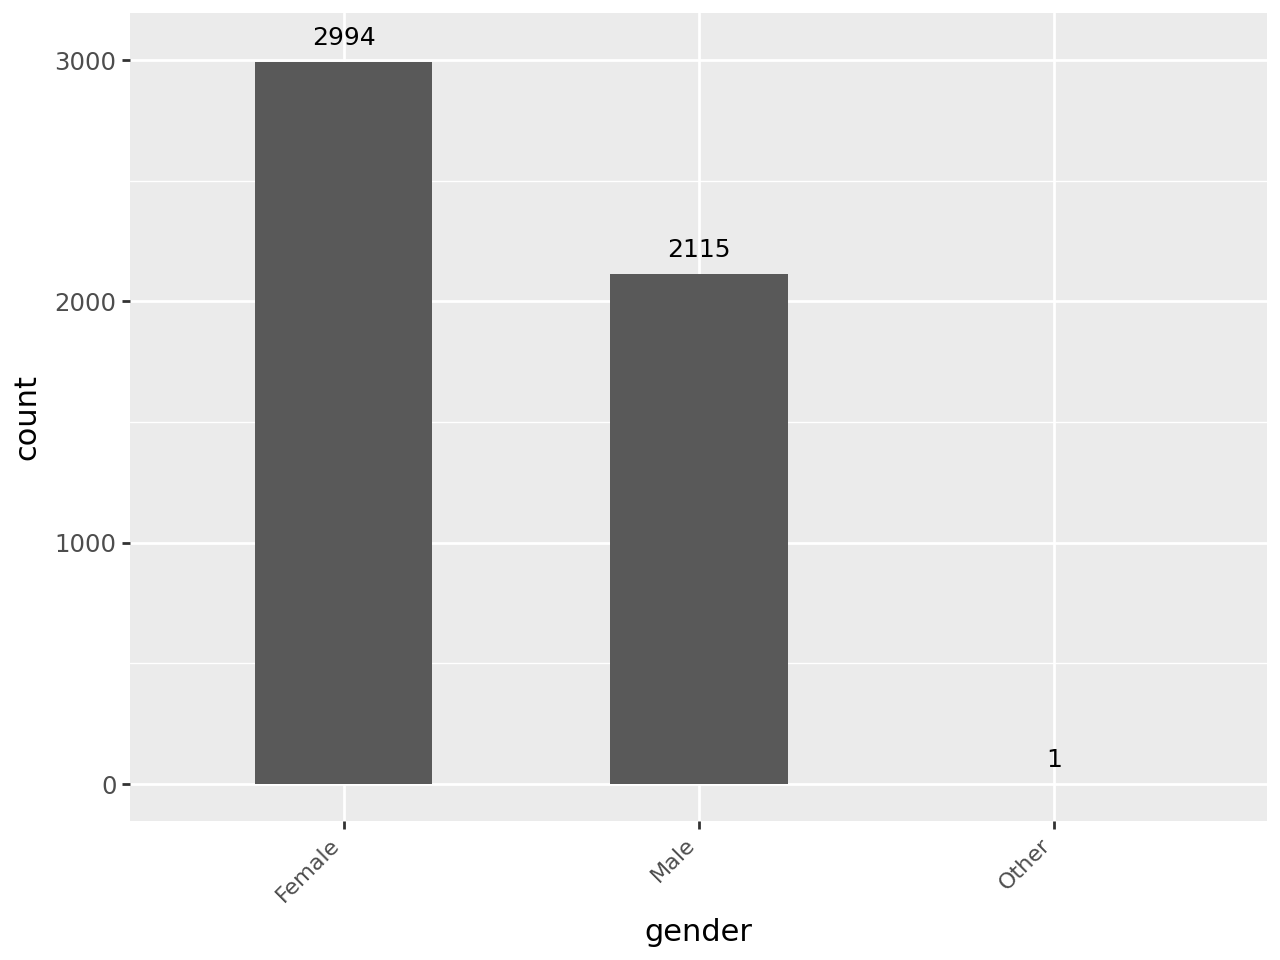

In [26]:
(
    pln.ggplot(df, pln.aes(x="gender"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Age*

Tere is pretty uniform distribution of samples

In [27]:
df["age"].value_counts()

age
78.00    102
57.00     95
52.00     90
54.00     87
51.00     86
        ... 
1.40       3
0.48       3
0.16       3
0.40       2
0.08       2
Name: count, Length: 104, dtype: int64

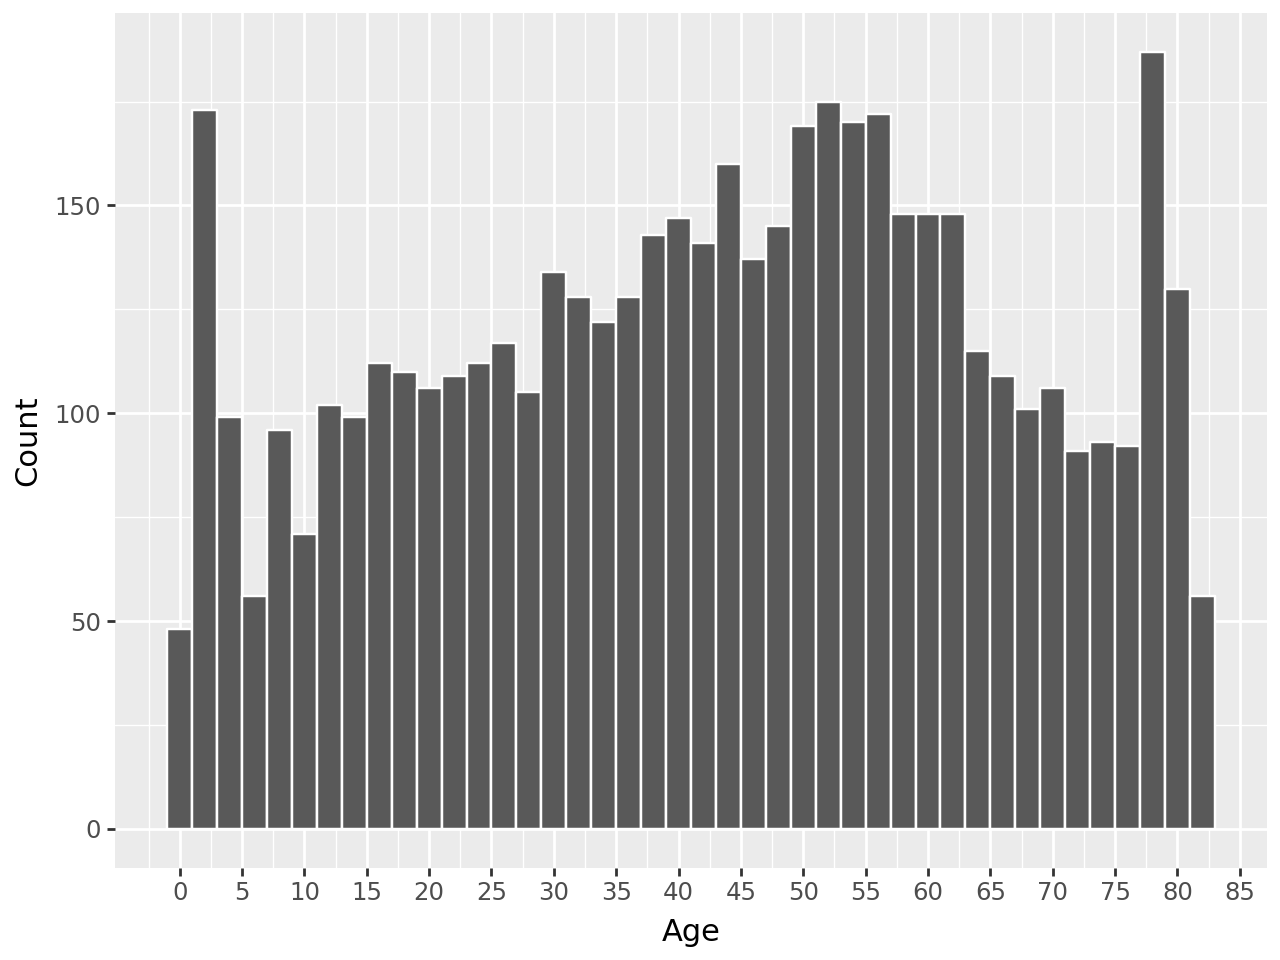

In [28]:
(
    pln.ggplot(df, pln.aes(x="age"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 90, 5)
    )
    + pln.labs(x="Age", y="Count")
)

In [29]:
df["age"].describe()

count    5110.000000
mean       43.226614
std        22.612647
min         0.080000
25%        25.000000
50%        45.000000
75%        61.000000
max        82.000000
Name: age, dtype: float64

#### *Hypertension*

hypertension = over blood flow preasure.

Most of the population has no history of hypertension. The data make sense.

In [30]:
df["hypertension"].value_counts()

hypertension
0    4612
1     498
Name: count, dtype: int64

In [31]:
df["hypertension"].describe()

count    5110.000000
mean        0.097456
std         0.296607
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: hypertension, dtype: float64

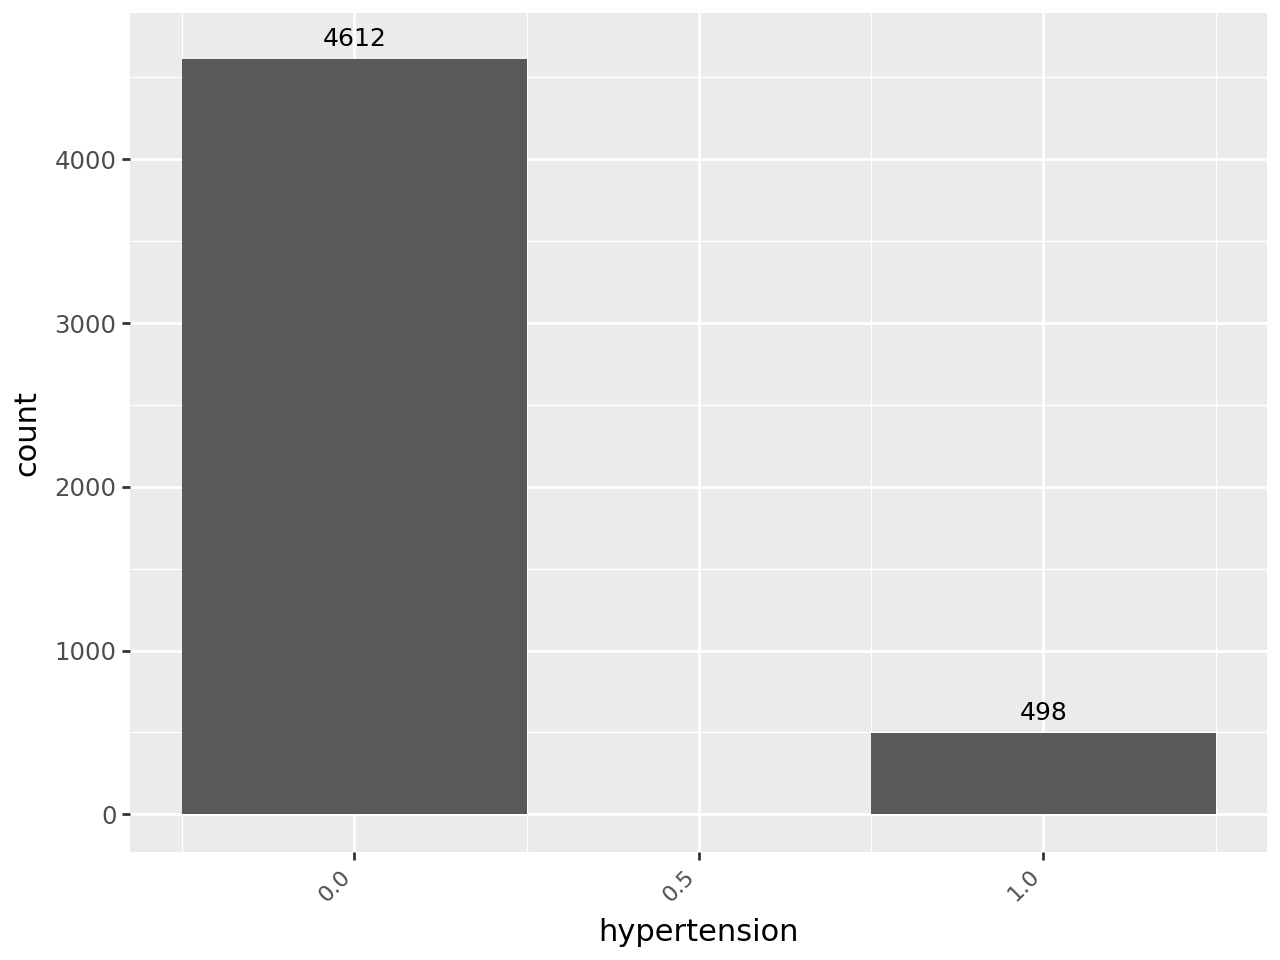

In [32]:
(
    pln.ggplot(df, pln.aes(x="hypertension"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Heart disease*

Most of the population has no history of heart disease. The data make sense.

In [33]:
df["heart_disease"].value_counts()

heart_disease
0    4834
1     276
Name: count, dtype: int64

In [34]:
df["heart_disease"].describe()


count    5110.000000
mean        0.054012
std         0.226063
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: heart_disease, dtype: float64

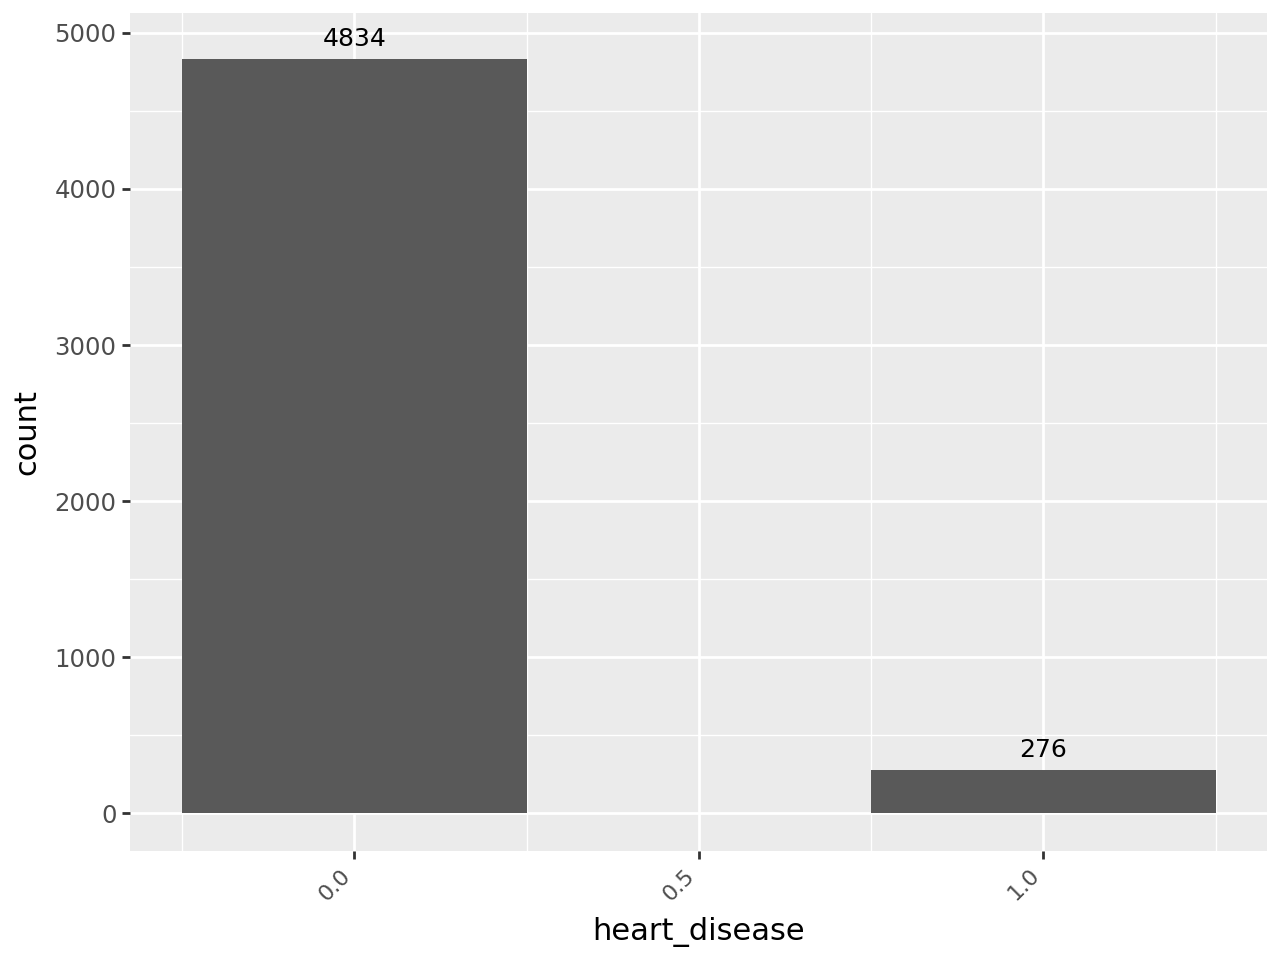

In [35]:
(
    pln.ggplot(df, pln.aes(x="heart_disease"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Marriage*

##### *General*

Proper marraiage distribution. There are no youth marriage cases.

In [36]:
df["ever_married"].value_counts()

ever_married
Yes    3353
No     1757
Name: count, dtype: int64

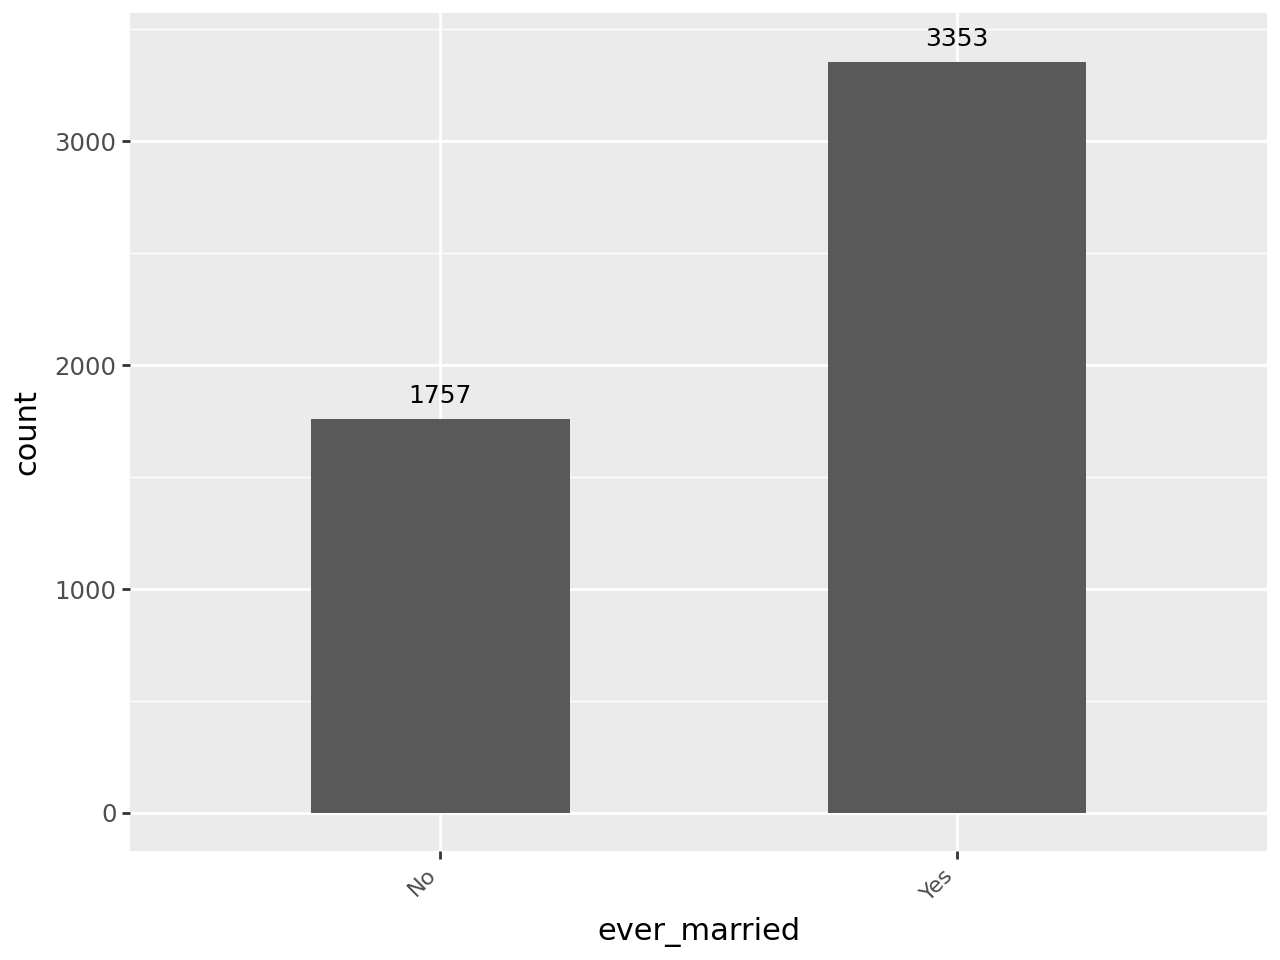

In [37]:
(
    pln.ggplot(df, pln.aes(x="ever_married"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

##### *Married people analysis*

In [38]:
married_df = df[df["ever_married"] == "Yes"].copy()
married_df["age"].describe()

count    3353.000000
mean       54.342082
std        15.527678
min        18.000000
25%        42.000000
50%        54.000000
75%        66.000000
max        82.000000
Name: age, dtype: float64

In [39]:
married_df["age"].value_counts()

age
78.0    89
57.0    87
54.0    83
52.0    83
53.0    81
        ..
22.0     7
21.0     6
20.0     4
19.0     2
18.0     1
Name: count, Length: 65, dtype: int64

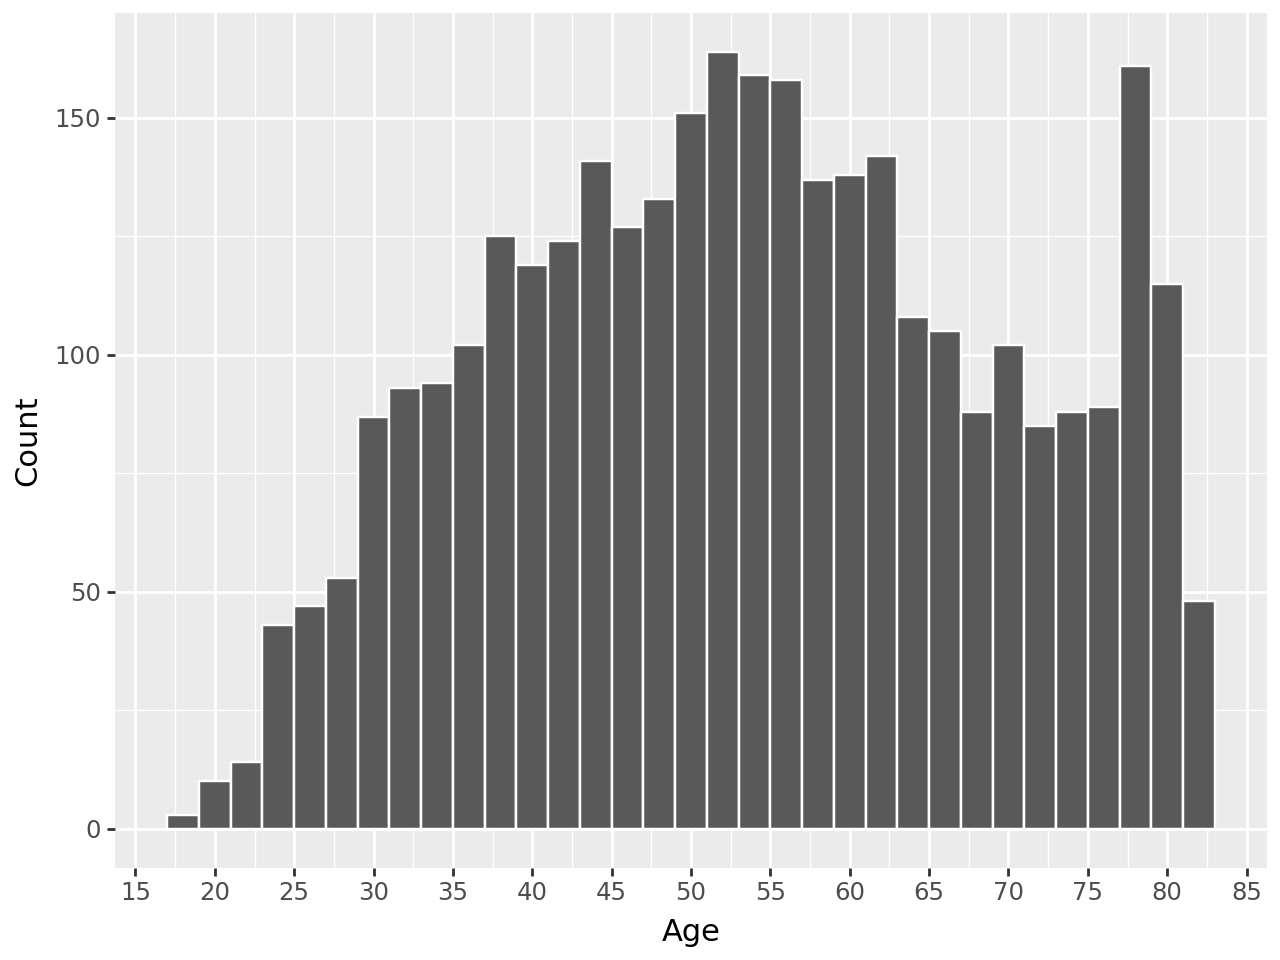

In [40]:
(
    pln.ggplot(married_df, pln.aes(x="age"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 90, 5)
    )
    + pln.labs(x="Age", y="Count")
)

##### *Not married analysis*

In [41]:
not_married_df = df[df["ever_married"] == "No"].copy()
not_married_df["age"].describe()

count    1757.000000
mean       22.014229
std        18.474467
min         0.080000
25%         9.000000
50%        18.000000
75%        28.000000
max        82.000000
Name: age, dtype: float64

In [42]:
not_married_df["age"].value_counts()

age
5.0     65
17.0    60
18.0    59
8.0     58
23.0    57
        ..
74.0     2
63.0     2
77.0     1
70.0     1
72.0     1
Name: count, Length: 103, dtype: int64

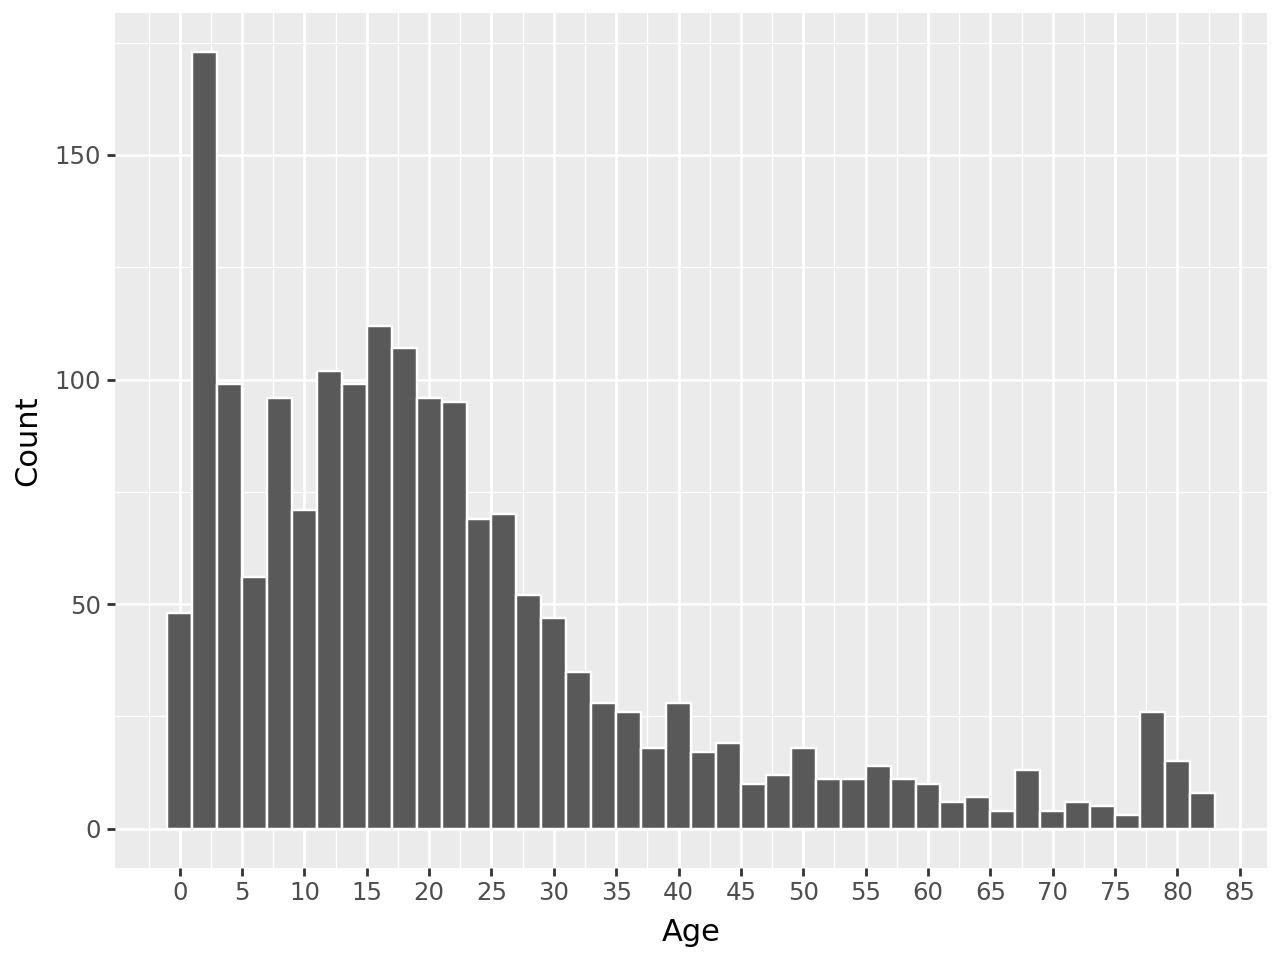

In [43]:
(
    pln.ggplot(not_married_df, pln.aes(x="age"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 90, 5)
    )
    + pln.labs(x="Age", y="Count")
)

The majority of the not married are children as expected.

#### *Work type*

##### *General*

The majority of the sampled people in the data are private workers. represents the entire population.

In [44]:
df["work_type"].value_counts()

work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

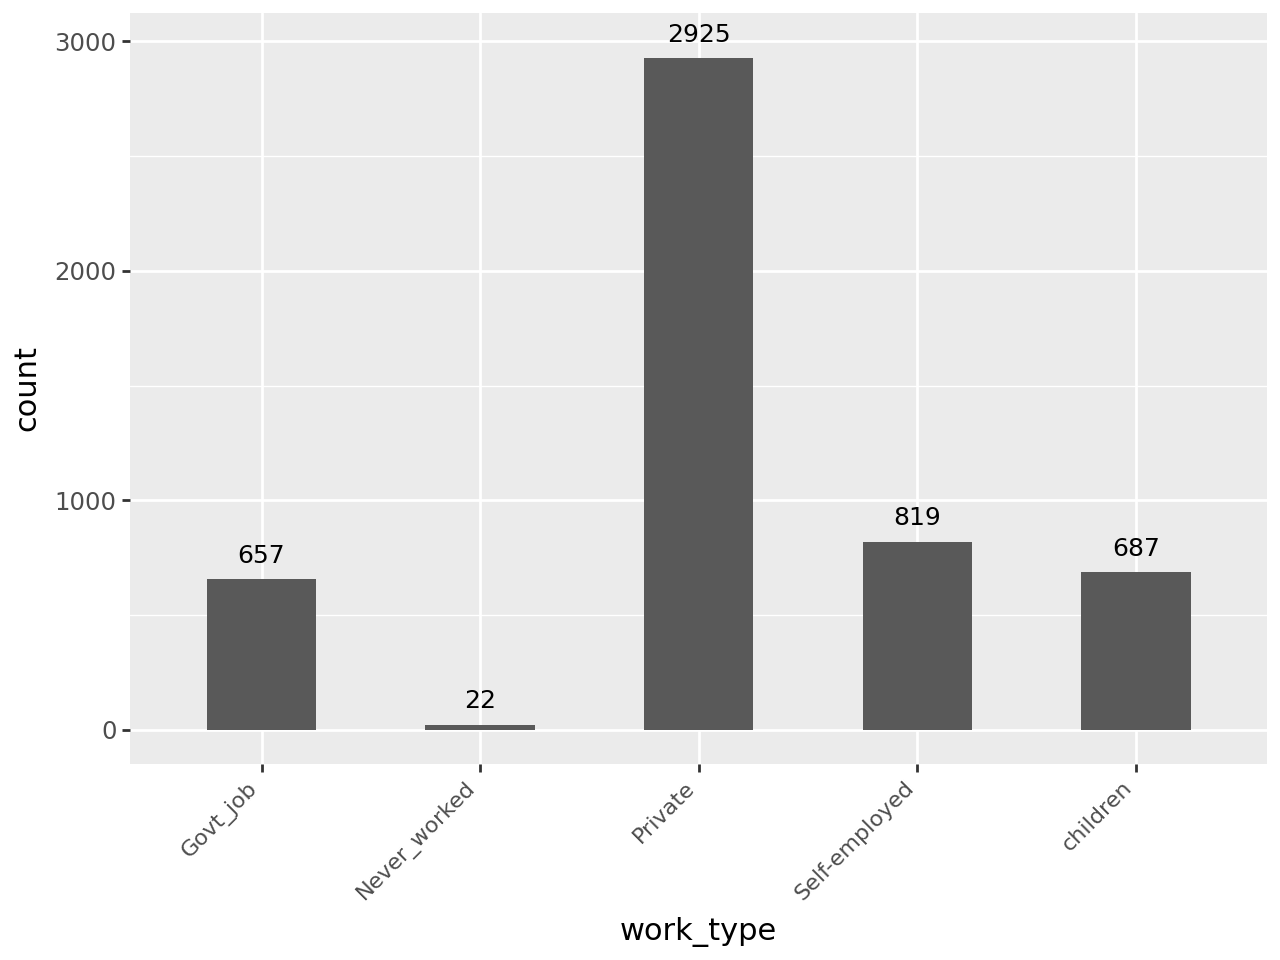

In [45]:
(
    pln.ggplot(df, pln.aes(x="work_type"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

##### *Work type - age analysis*

In [46]:
work_age_stats = df.groupby("work_type")["age"]
work_age_stats.describe()

,count,mean,std,min,25%,50%,75%,max
work_type,,,,,,,,
Govt_job,657.0,50.879756,15.438879,14.00,40.00,51.0,62.0,82.0
Never_worked,22.0,16.181818,2.342899,13.00,14.25,16.0,17.0,23.0
Private,2925.0,45.503932,18.444200,8.00,30.00,45.0,59.0,82.0
Self-employed,819.0,60.201465,16.835961,7.00,49.00,63.0,75.0,82.0
children,687.0,6.841339,4.533364,0.08,2.00,6.0,11.0,16.0


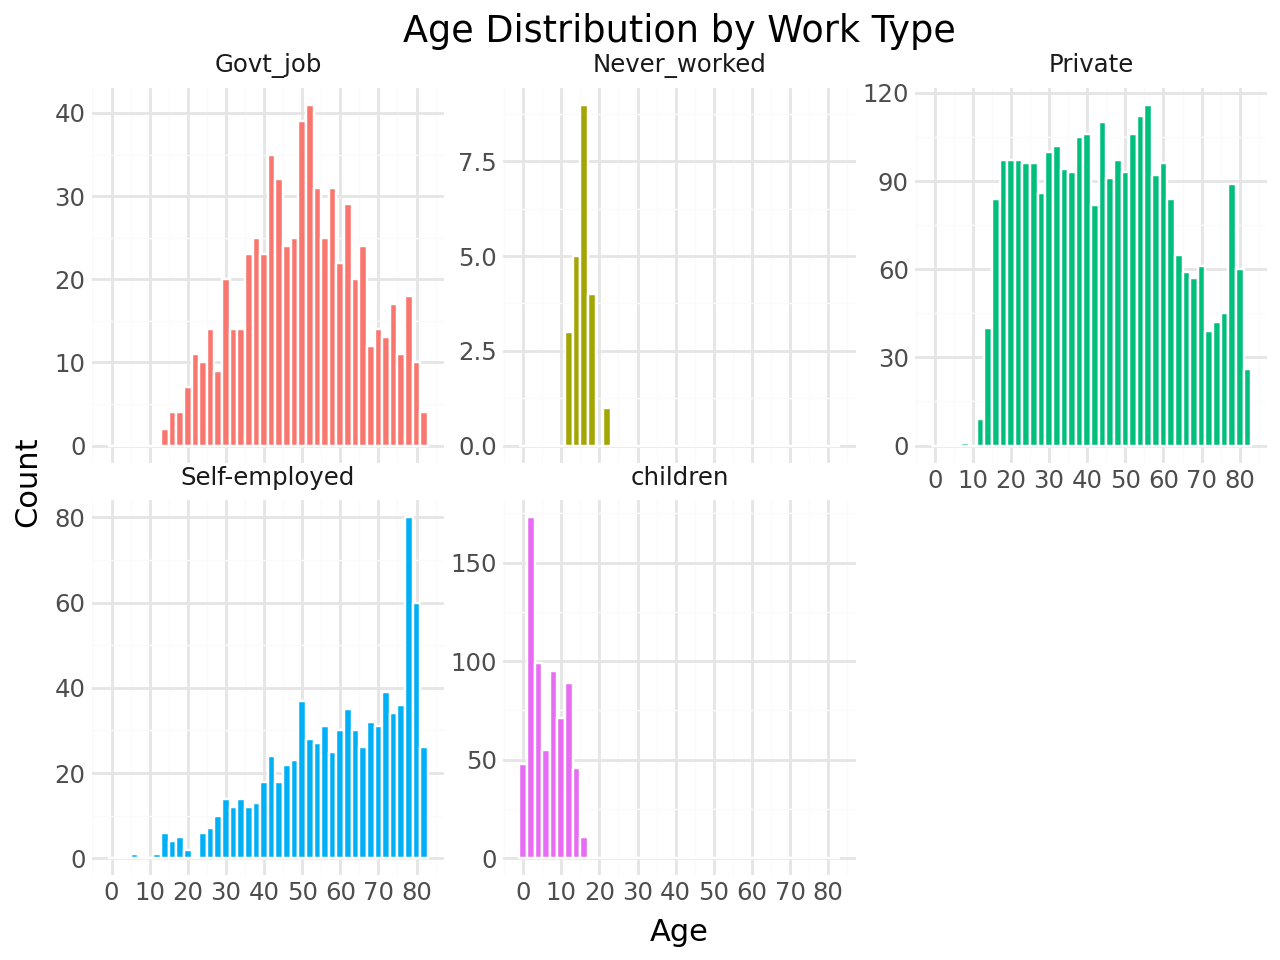

In [47]:
chart_all = (
    pln.ggplot(df, pln.aes(x='age', fill='work_type'))
    + pln.geom_histogram(binwidth=2, color='white', show_legend=False)
    + pln.facet_wrap('~work_type', scales='free_y')
    + pln.scale_x_continuous(breaks=range(0, 95, 10))
    + pln.labs(title='Age Distribution by Work Type', x='Age', y='Count')
    + pln.theme_minimal()
)

display(chart_all)

The majority of the working sampled people are adults. represent the entire population distribution.

#### *Residence type*

In [48]:
df["Residence_type"].value_counts()

Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

In [49]:
df["Residence_type"].describe()

count      5110
unique        2
top       Urban
freq       2596
Name: Residence_type, dtype: object

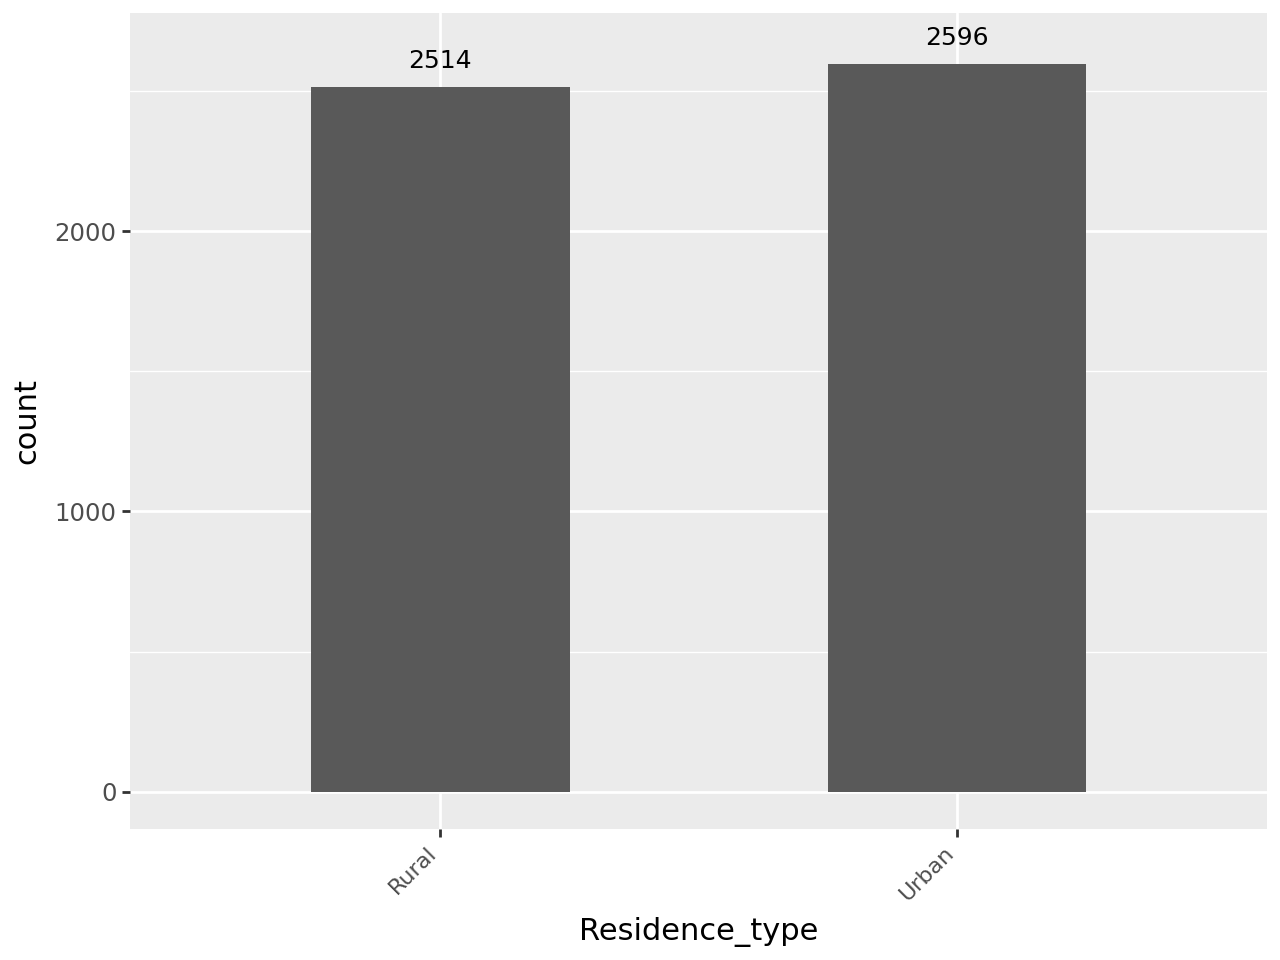

In [50]:
(
    pln.ggplot(df, pln.aes(x="Residence_type"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Average glucose level*

The data exhibits a bimodal distribution, comprising a primary normal distribution centered around a healthy avg glucose level, alongside a smaller, secondary normal distribution centered around an elevated average. This latter subpopulation likely represents individuals with potential pathological conditions.

In [51]:
df["avg_glucose_level"].value_counts()


avg_glucose_level
93.88     6
73.00     5
72.49     5
91.68     5
91.85     5
         ..
83.94     1
125.20    1
82.99     1
166.29    1
85.28     1
Name: count, Length: 3979, dtype: int64

In [52]:
df["avg_glucose_level"].describe()

count    5110.000000
mean      106.147677
std        45.283560
min        55.120000
25%        77.245000
50%        91.885000
75%       114.090000
max       271.740000
Name: avg_glucose_level, dtype: float64

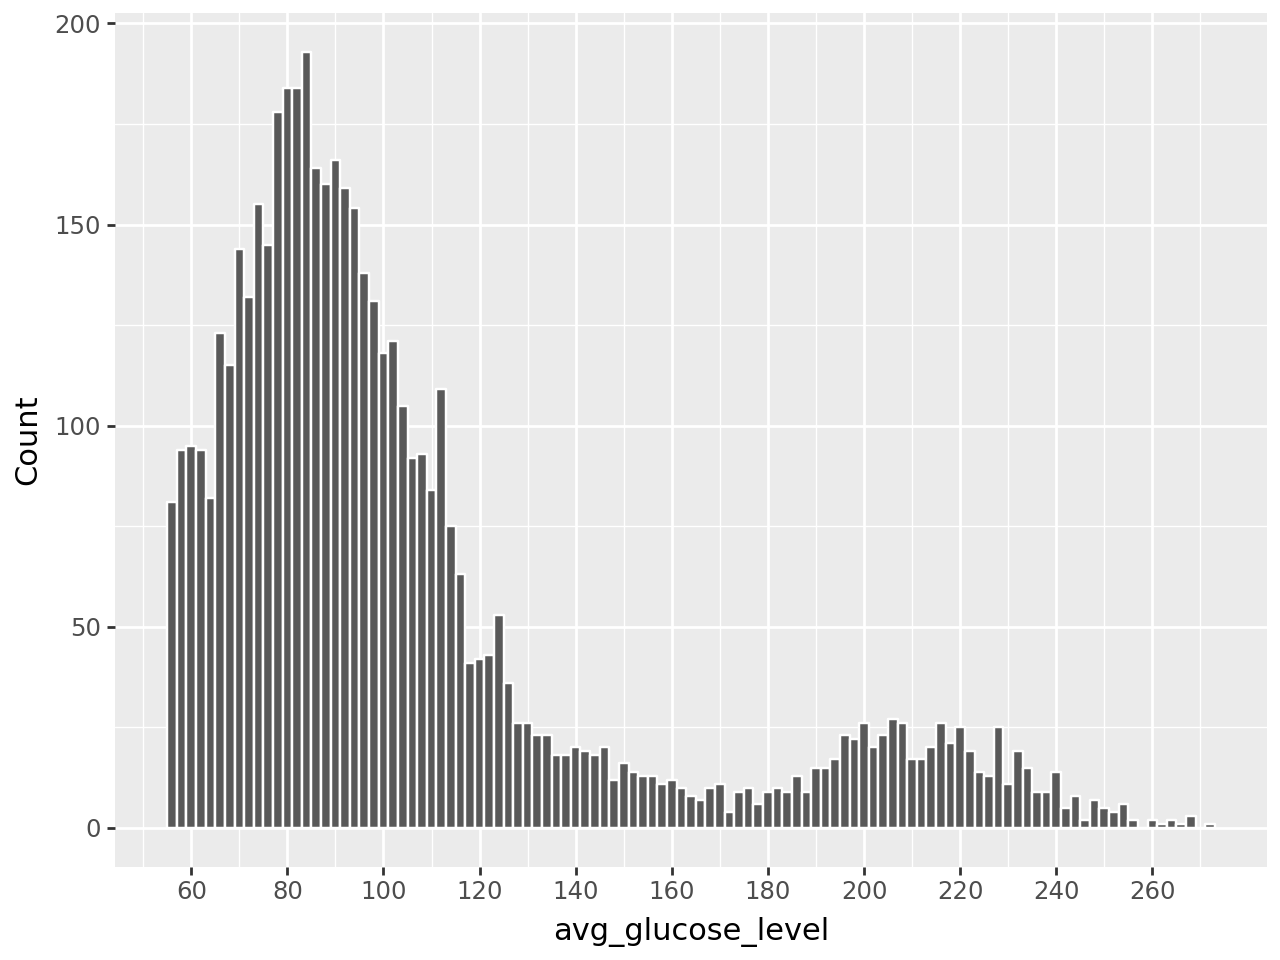

In [53]:
(
    pln.ggplot(df, pln.aes(x="avg_glucose_level"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 280, 20)
    )
    + pln.labs(x="avg_glucose_level", y="Count")
)

#### *BMI*

* **Distribution Profile:** The BMI metric exhibits a classic unimodal, right-skewed (positively skewed) distribution, with the peak mode centered around $25–28 \text{ kg/m}^2$.
* **Population Alignment:** This positive skew closely mirrors real-world adult epidemiological data, where population BMI values typically exhibit a concentration in the normal/overweight range with an extended upper tail corresponding to higher obesity classes.
* **Representativeness:** The overall shape and density spread demonstrate that the sample accurately reflects typical general-population health indicators, making it a reliable feature for downstream statistical analysis and predictive modeling.

In [54]:
df["bmi"].value_counts()

bmi
28.7    41
28.4    38
27.7    37
26.7    37
26.1    37
        ..
48.1     1
51.7     1
46.3     1
54.1     1
14.9     1
Name: count, Length: 418, dtype: int64

In [55]:
df["bmi"].describe()

count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64

Missing BMI values account for 201 out of 5,110 observations (~3.9%), which constitutes a negligible amount of data.

In [56]:
df["bmi"].isnull().sum()

np.int64(201)

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_bin : Removed 201 rows containing non-finite values.


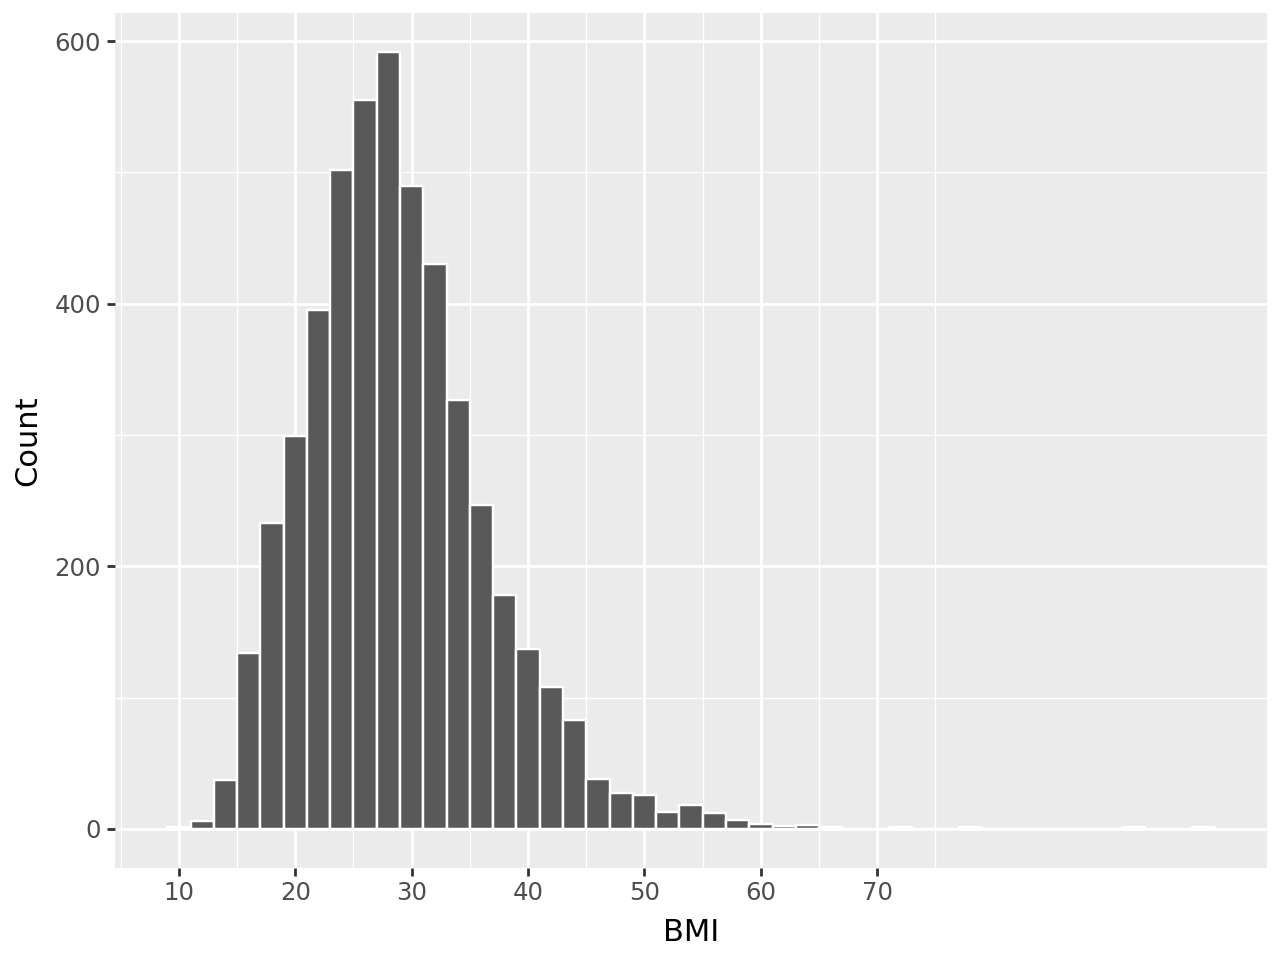

In [57]:
(
    pln.ggplot(df, pln.aes(x="bmi"))
    + pln.geom_histogram(
        binwidth=2, color="white"
    )
    + pln.scale_x_continuous(
        breaks=range(0, 80, 10)
    )
    + pln.labs(x="BMI", y="Count")
)

#### *Smoking status*

* **High Proportion of Missing Data:** The `smoking_status` feature contains **1,544 `Unknown` entries**, representing roughly **30% of the entire dataset**.
* **Clinical Significance Paradox:** Clinical literature strongly establishes tobacco smoking as a primary independent risk factor for ischemic and hemorrhagic stroke. Having a missing/unknown status for nearly a third of the cohort introduces substantial aleatoric uncertainty and potential bias into the model.
* **Domain Impact on Target Variable (`stroke`):** Because smoking status directly modulates vascular health and stroke probability, this high level of unobserved data limits the feature's predictive utility unless properly handled.
* **Modeling Strategy:**
  * **Explicit Categorical Encoding:** Retain `Unknown` as a standalone structural category rather than dropping rows, as the missingness pattern may not be Missing Completely at Random (MCAR) and could correlate with specific patient demographics or age groups.
  * **Sensitivity Analysis:** Evaluate model feature importance to monitor whether the `Unknown` category distorts signal propagation regarding stroke risk prediction.

In [58]:
df["smoking_status"].value_counts()

smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [59]:
df["smoking_status"].describe()

count             5110
unique               4
top       never smoked
freq              1892
Name: smoking_status, dtype: object

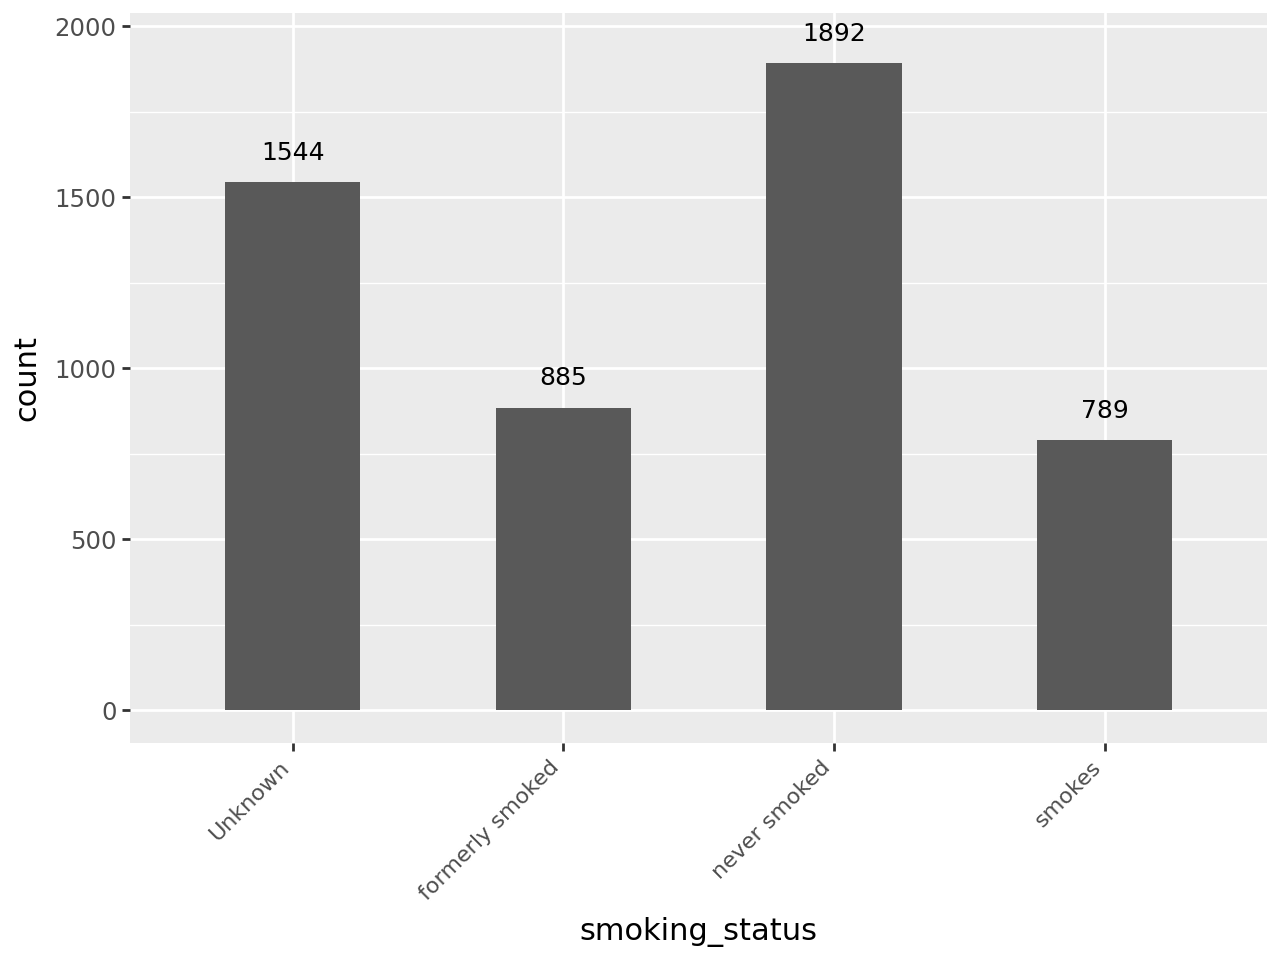

In [60]:
(
    pln.ggplot(df, pln.aes(x="smoking_status"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

#### *Stroke*

* **Real-World Alignment:** Only ~5% of patients in this dataset experienced a stroke. This accurately reflects real-life health data, where stroke is a relatively rare event.
* **The Model Trap:** A naive model predicting "No Stroke" for every patient would easily reach ~95% accuracy, yet fail completely at detecting actual stroke cases.
* **Key Strategy:**
  * Avoid relying on standard **Accuracy**.
  * Focus on **Recall** (Sensitivity) to capture as many true stroke cases as possible.
  * Apply class weighting during training to force the model to pay extra attention to stroke instances.

In [61]:
df["stroke"].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

In [62]:
df["stroke"].describe()

count    5110.000000
mean        0.048728
std         0.215320
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: stroke, dtype: float64

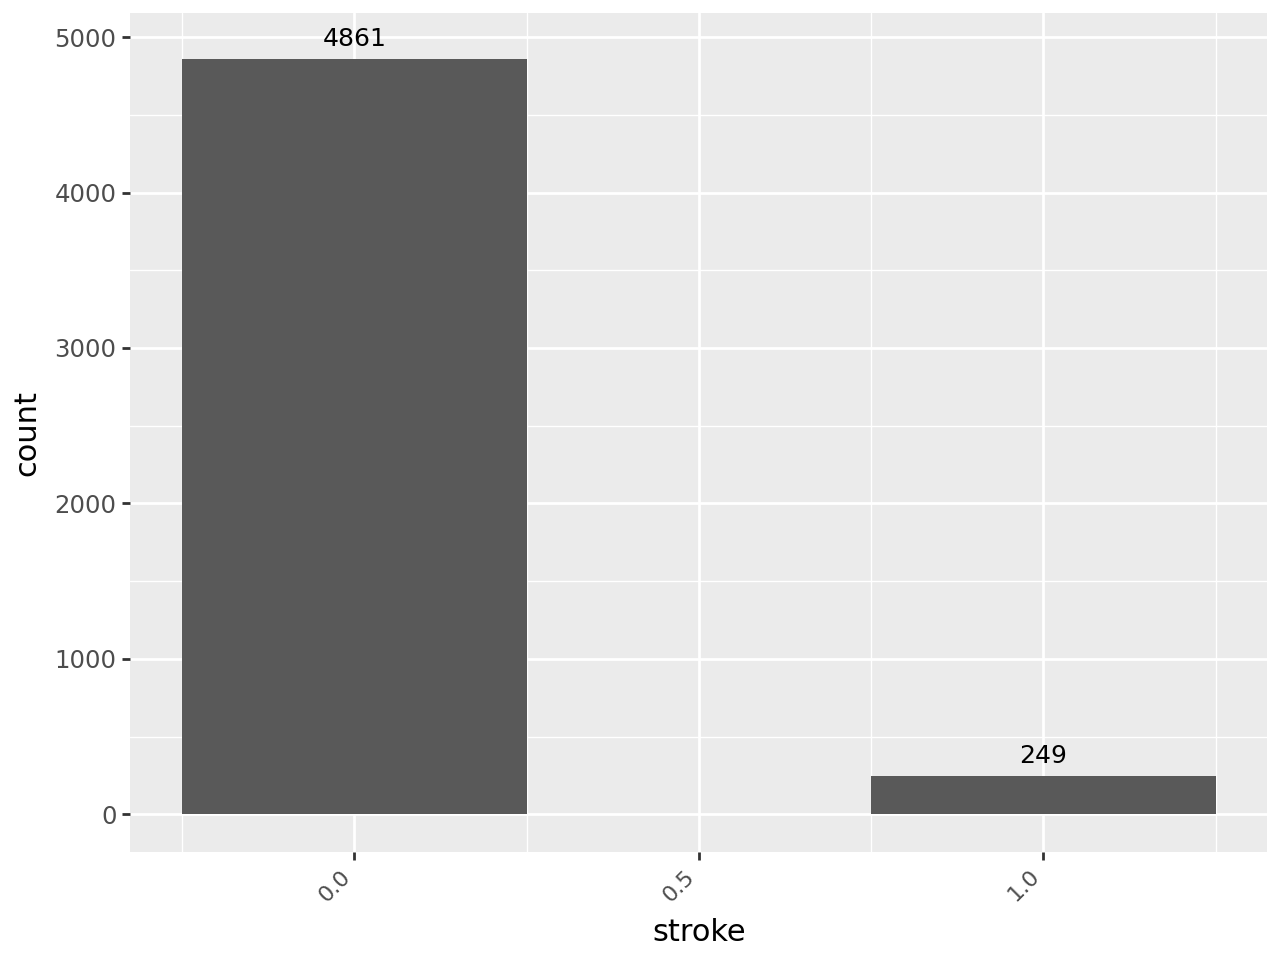

In [63]:
(
    pln.ggplot(df, pln.aes(x="stroke"))
    + pln.geom_bar(width=0.5)
    + pln.geom_text(
        pln.aes(label="stat(count)"),
        stat="count",
        va="bottom",
        nudge_y=50,
        size=9,
    )
    + pln.theme(axis_text_x=pln.element_text(size=8, angle=45, hjust=1))
)

## 3. *Bivariate and corelation analysis*

### 3.1 *Numerical parameters corelation analysis*

* **Primary Risk Driver:** `age` exhibits the strongest direct association with `stroke` ($r \approx 0.25$), confirming age as the dominant clinical demographic indicator.
* **The BMI Paradox:** `BMI` demonstrates a surprisingly weak linear correlation with `stroke` ($r \approx 0.05$). Bivariate analysis indicates that BMI operates as an indirect risk factor mediated through `hypertension` and elevated `avg_glucose_level`.
* **Linear vs. Monotonic Discrepancies:** Spearman rank correlation values consistently exceed Pearson correlation values across skewed continuous predictors (`age`, `avg_glucose_level`). This structural divergence proves the existence of **non-linear threshold relationships**, demonstrating that stroke risk accelerates non-linearly past clinical tipping points.

In [68]:
# Filter all numerical columns
num_df = df.select_dtypes(include=['number'])

# Calculate correlation matrices for each method
pearson_corr = num_df.corr(method='pearson')
spearman_corr = num_df.corr(method='spearman')
kendall_corr = num_df.corr(method='kendall')

# Display rounded matrices (2 decimal places for clean layout)
print("=== Pearson Correlation Matrix ===")
display(pearson_corr.round(2))

print("\n=== Spearman Correlation Matrix ===")
display(spearman_corr.round(2))

print("\n=== Kendall Tau Correlation Matrix ===")
display(kendall_corr.round(2))

=== Pearson Correlation Matrix ===


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.00,0.28,0.26,0.24,0.34,0.25
hypertension,0.28,1.00,0.11,0.18,0.15,0.13
heart_disease,0.26,0.11,1.00,0.16,0.04,0.13
avg_glucose_level,0.24,0.18,0.16,1.00,0.18,0.13
bmi,0.34,0.15,0.04,0.18,1.00,0.04
stroke,0.25,0.13,0.13,0.13,0.04,1.00



=== Spearman Correlation Matrix ===


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.00,0.28,0.27,0.14,0.36,0.25
hypertension,0.28,1.00,0.11,0.12,0.16,0.13
heart_disease,0.27,0.11,1.00,0.11,0.06,0.13
avg_glucose_level,0.14,0.12,0.11,1.00,0.11,0.08
bmi,0.36,0.16,0.06,0.11,1.00,0.05
stroke,0.25,0.13,0.13,0.08,0.05,1.00



=== Kendall Tau Correlation Matrix ===


,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
age,1.00,0.23,0.22,0.10,0.25,0.21
hypertension,0.23,1.00,0.11,0.09,0.13,0.13
heart_disease,0.22,0.11,1.00,0.09,0.05,0.13
avg_glucose_level,0.10,0.09,0.09,1.00,0.08,0.07
bmi,0.25,0.13,0.05,0.08,1.00,0.04
stroke,0.21,0.13,0.13,0.07,0.04,1.00


In [73]:
import pandas as pd
import plotnine as pln

def create_plotnine_heatmap(corr_matrix, title="Correlation Matrix"):
    """
    Transforms a square correlation matrix into tidy format and
    renders a styled heatmap using plotnine.
    """
    # Reshape correlation matrix from wide to long format
    corr_long = corr_matrix.reset_index().melt(id_vars='index')
    corr_long.columns = ['Var1', 'Var2', 'Correlation']

    # Format values to 2 decimal places for text display
    corr_long['label'] = corr_long['Correlation'].round(2).astype(str)

    # Build the heatmap visualization
    heatmap = (
        pln.ggplot(corr_long, pln.aes(x='Var1', y='Var2', fill='Correlation'))
        + pln.geom_tile(color='white', size=0.5)
        + pln.geom_text(pln.aes(label='label'), size=8, color='black')
        + pln.scale_fill_gradient2(
            low='#4575b4',      # Blue for negative correlation
            mid='#f7f7f7',      # Neutral for zero
            high='#d73027',     # Red for positive correlation
            midpoint=0,
            limits=[-1, 1]
        )
        + pln.coord_fixed()
        + pln.theme_minimal()
        + pln.theme(
            axis_text_x=pln.element_text(rotation=45, hjust=1),
            axis_title_x=pln.element_blank(),
            axis_title_y=pln.element_blank(),
            figure_size=(7, 6)
        )
        + pln.labs(title=title, fill="Correlation")
    )
    return heatmap

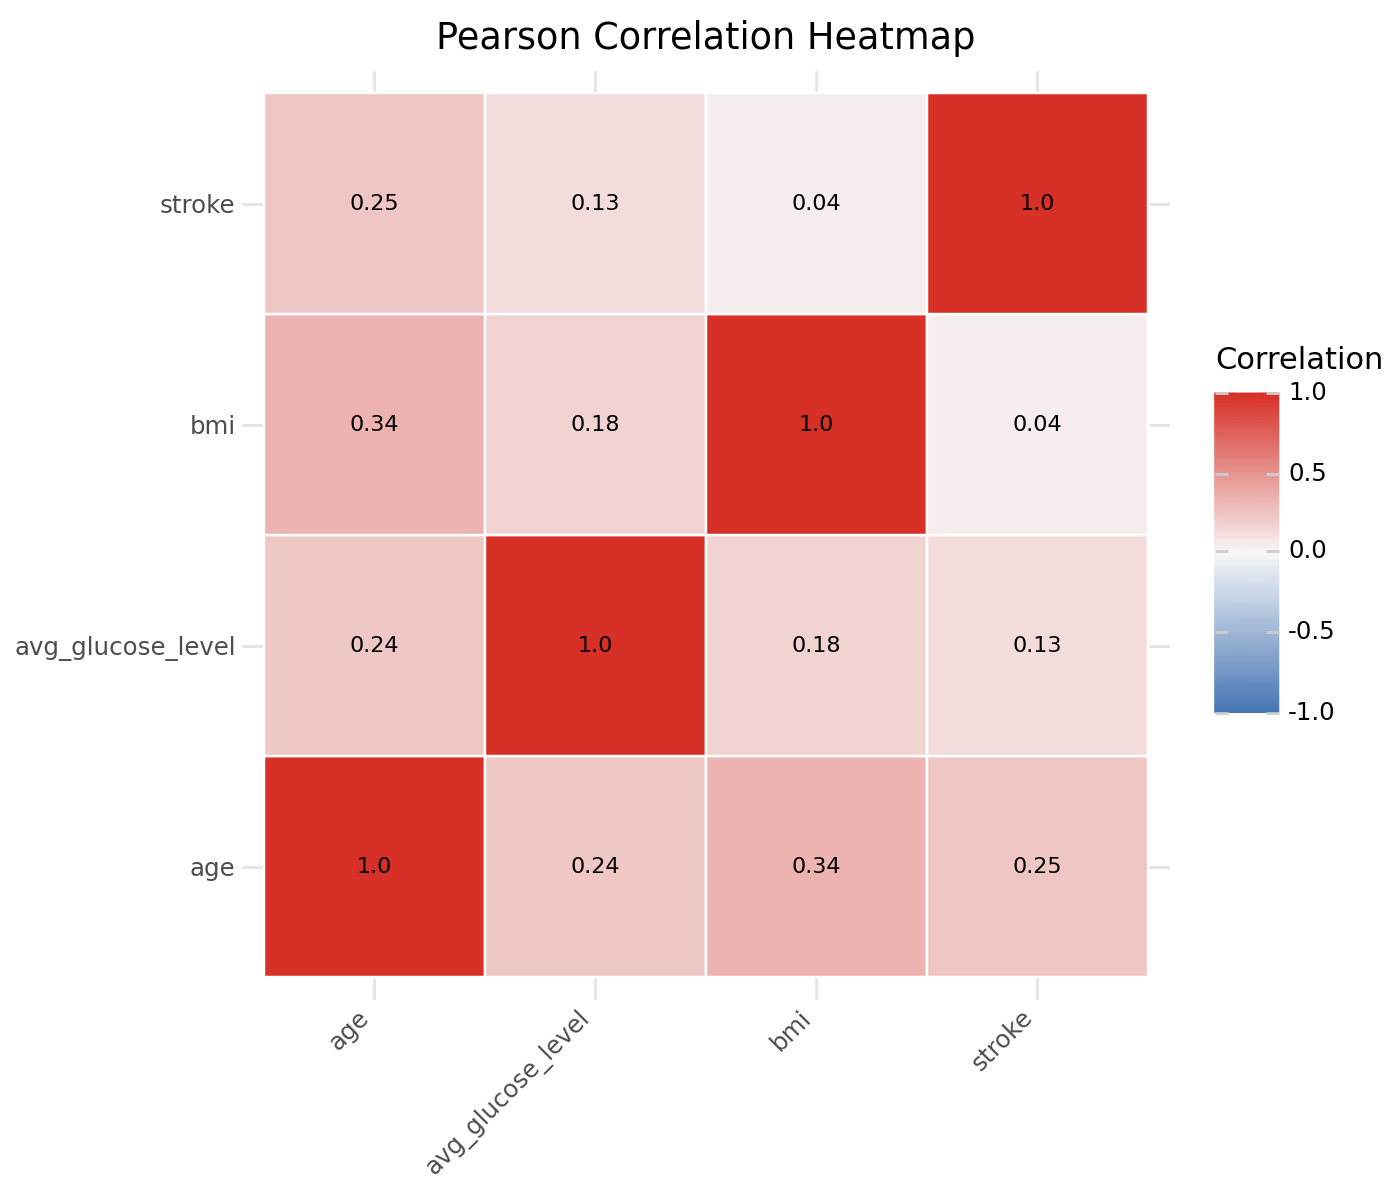

In [74]:
# Target numerical columns using lowercase 'bmi'
numeric_cols = ['age', 'avg_glucose_level', 'bmi', 'stroke']

# Calculate Pearson correlation matrix
pearson_corr = df[numeric_cols].corr(method='pearson')

# Render Pearson heatmap (leaving the object at the end of the cell displays it)
p1 = create_plotnine_heatmap(pearson_corr, title="Pearson Correlation Heatmap")
p1

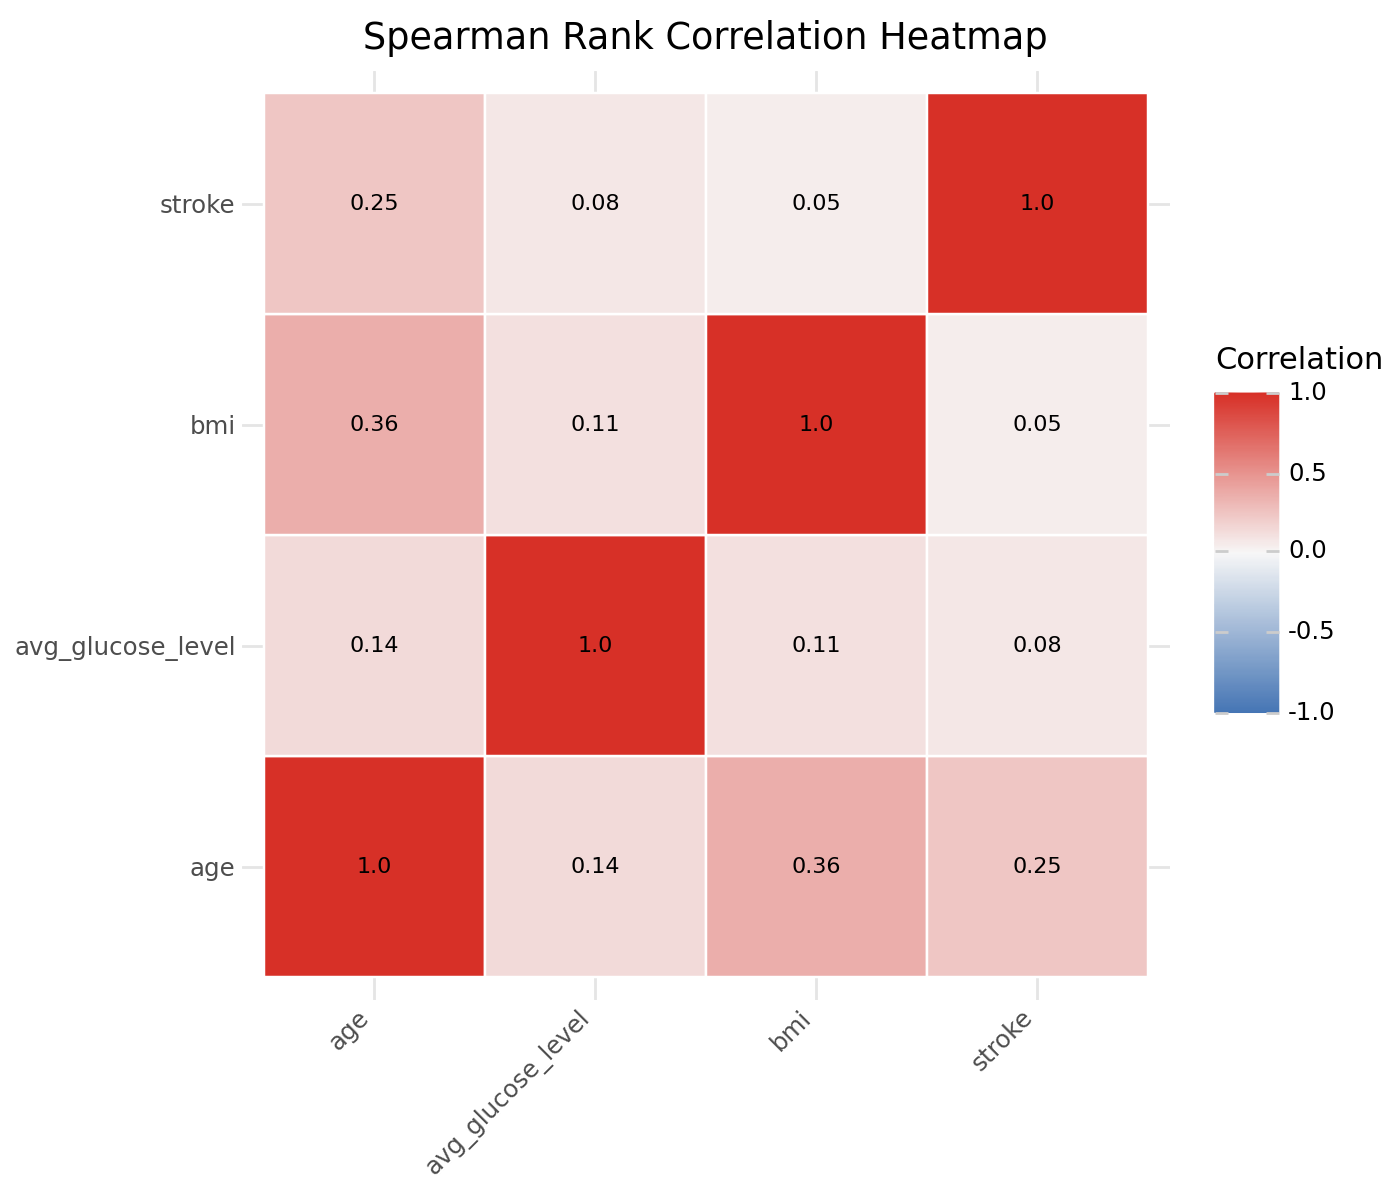

In [75]:
# Calculate Spearman correlation matrix
spearman_corr = df[numeric_cols].corr(method='spearman')

# Render Spearman heatmap (leaving the object at the end of the cell displays it)
p2 = create_plotnine_heatmap(spearman_corr, title="Spearman Rank Correlation Heatmap")
p2

### 3.2 *Categorial parameters corelation analysis*


Evaluating Cramér's V coefficients across all categorical and binary indicators (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`, `hypertension`, `heart_disease`, `stroke`) reveals key structural dependencies and isolates uninformative features:

* **Strong Demographic Dependency (`ever_married` $\leftrightarrow$ `work_type`):** Displays a strong association ($V > 0.35$). This is driven by structural age dynamics—younger cohorts and children belong exclusively to `ever_married == 'No'` and `work_type == 'children'`, whereas adult employment types (`Private`, `Self-employed`, `Govt_job`) align with married demographics.
* **Non-Random Missingness Pattern (`smoking_status` $\leftrightarrow$ Demographics):** `smoking_status` exhibits moderate association with `work_type` and `ever_married`. This confirms that the high prevalence of `Unknown` entries in smoking status is non-random, heavily clustering within pediatric and younger demographic groups (`work_type == 'children'`).
* **Clinical Comorbidities (`hypertension` $\leftrightarrow$ `heart_disease` $\leftrightarrow$ `stroke`):** Binary clinical indicators demonstrate low-to-moderate association with `stroke`. While presence of hypertension or heart disease elevates relative risk, the overall Cramér's V remains bounded due to the extreme target class imbalance (~4.87% positive cases).
* **Identification of Uninformative / Noise Features (`Residence_type`):** `Residence_type` (Urban vs. Rural) demonstrates near-zero statistical association ($V < 0.05$) across all categorical attributes and the target variable `stroke`. This strongly suggests that geographic setting carries negligible predictive signal in this cohort and can be considered for exclusion during feature selection.

C:\Users\idowe\AppData\Local\Temp\ipykernel_46864\883886631.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


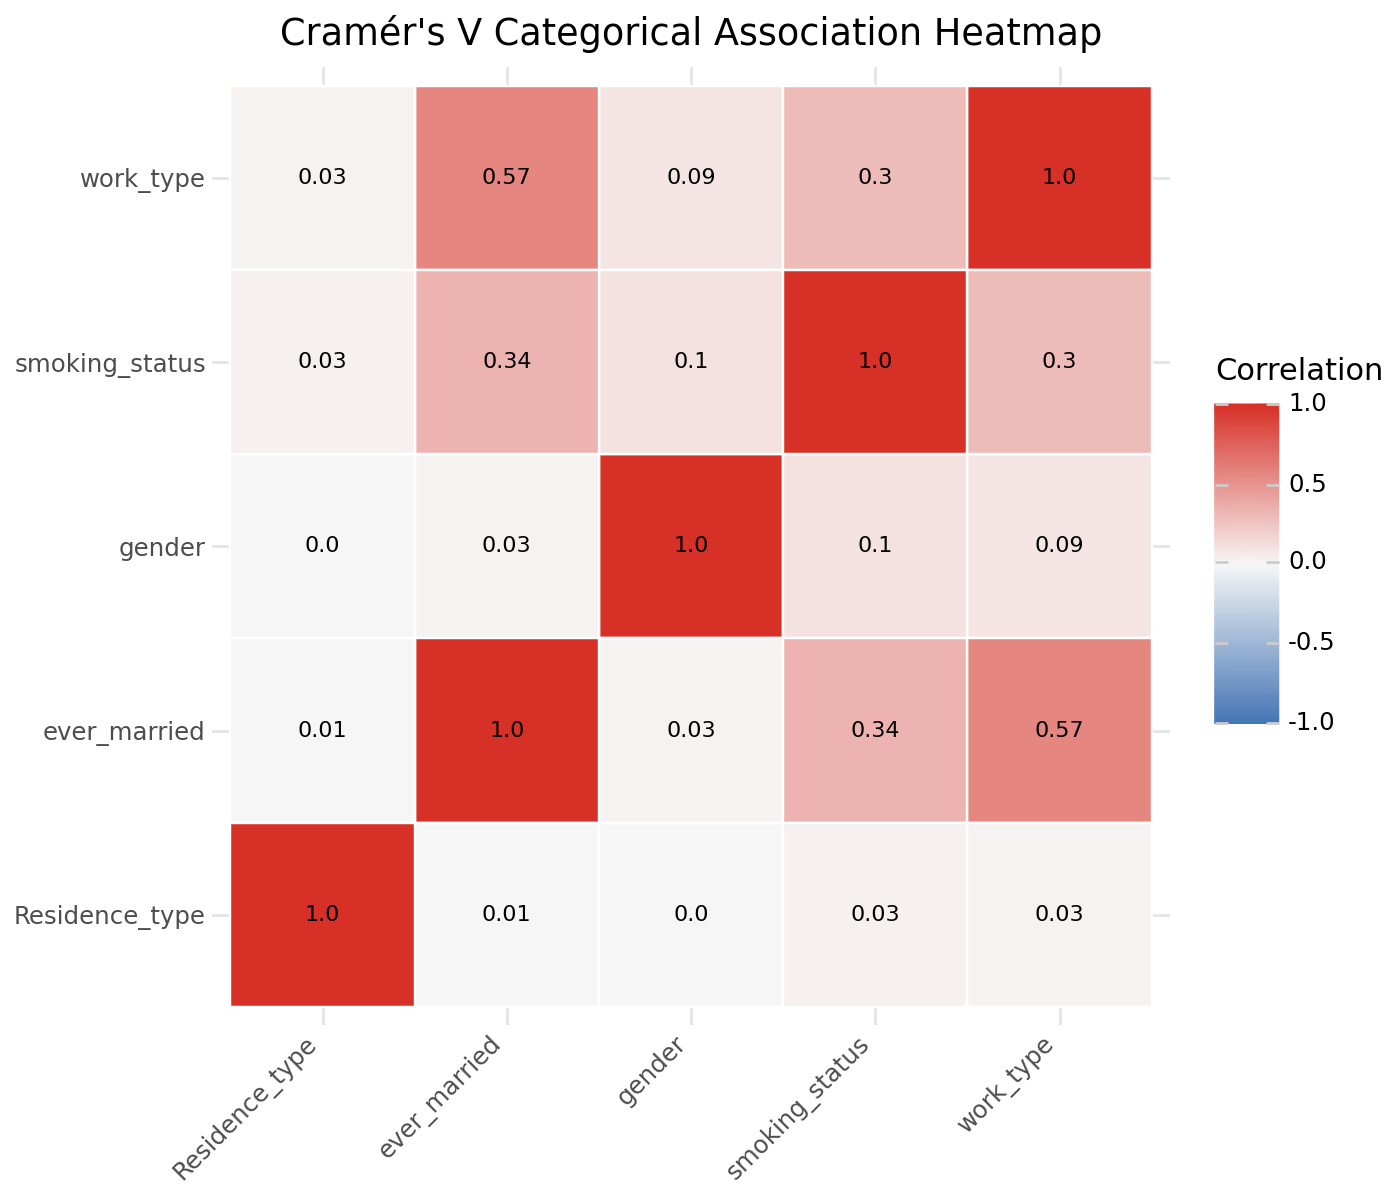

In [76]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency


def cramers_v(x, y):
  """Calculate Cramer's V statistic for categorical-categorical association."""
  ct = pd.crosstab(x.fillna('Unknown'), y.fillna('Unknown'))
  chi2 = chi2_contingency(ct)[0]
  n = ct.sum().sum()
  r, k = ct.shape

  min_dim = min(k - 1, r - 1)
  if min_dim == 0:
    return 0.0

  return np.sqrt(chi2 / (n * min_dim))


# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Calculate Cramer's V matrix
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for col1 in cat_cols:
  for col2 in cat_cols:
    cramer_matrix.loc[col1, col2] = round(cramers_v(df[col1], df[col2]), 3)

# Render Heatmap using our plotnine function
p_cramer = create_plotnine_heatmap(
    cramer_matrix, title="Cramér's V Categorical Association Heatmap"
)
p_cramer

### 3.3 *Numeric & Categorial parameters corelation analysis*


#### *Mathematical Formulation of Mutual Information (MI)*

Mutual Information quantifies the mutual dependence between a feature $X$ and the target variable $Y$ (`stroke`), measuring the expected reduction in uncertainty (entropy) about $Y$ obtained by observing $X$.

---
### Intuitive Analogy: Entropy Reduction in Continuous-to-Categorical Relationships

To understand how Mutual Information measures the relationship between a **continuous numerical feature** ($X$) and a **categorical target** ($Y$), consider the following clinical analogy:

#### 1. Baseline High Entropy (Maximum Uncertainty)
* **Scenario:** You evaluate a cohort of 100 patients to predict flu status ($Y \in \{\text{Positive}, \text{Negative}\}$).
* **Initial Distribution:** 50 patients are flu-positive and 50 are healthy.
* **Entropy State:** Uncertainty is at its maximum ($H(Y) = 1 \text{ bit}$). Predicting status without additional information is equivalent to a random coin flip.

#### 2. Observing the Continuous Predictor ($X$)
* **Action:** You measure each patient's exact body temperature in degrees Celsius ($X \in \mathbb{R}$).

#### 3. Conditional Entropy Reduction
* **High Temperature Region ($X \ge 38.5^\circ\text{C}$):** Among 40 patients in this range, 38 are flu-positive and 2 are healthy. Class uncertainty within this partition drops near zero ($H(Y \mid X \ge 38.5) \approx 0.24 \text{ bits}$).
* **Normal Temperature Region ($X \le 37.0^\circ\text{C}$):** Among 60 patients in this range, 58 are healthy and 2 are flu-positive. Uncertainty here similarly collapses ($H(Y \mid X \le 37.0) \approx 0.24 \text{ bits}$).

#### 4. Connection to Mutual Information
* **High Mutual Information:** Because body temperature segments the data into subsets where target ambiguity virtually disappears, the average reduction in uncertainty—**Information Gain** ($I(X; Y) = H(Y) - H(Y|X)$)—is substantial.
* **Zero Mutual Information:** If patient height was measured instead, the 50/50 flu ratio would persist across all height ranges. Conditional entropy would remain equal to baseline entropy ($H(Y|X) = H(Y)$), yielding $I(X;Y) = 0$.
---


#### 1. Information-Theoretic Foundations

* **Target Shannon Entropy $H(Y)$:** Measures the baseline uncertainty of the binary target class $Y \in \{0, 1\}$:
  $$H(Y) = -\sum_{y \in \{0, 1\}} P(y) \log_2 P(y)$$

* **Conditional Entropy $H(Y|X)$:** Measures the residual uncertainty about $Y$ after observing feature $X$:
  $$H(Y|X) = -\int_{\mathcal{X}} P(x) \sum_{y \in \{0, 1\}} P(y|x) \log_2 P(y|x) \, dx$$

* **Mutual Information Definition:** Defined as the Information Gain or Kullback-Leibler ($D_{KL}$) Divergence between the joint distribution $P(X,Y)$ and the product of their marginal distributions $P(X)P(Y)$:
  $$I(X; Y) = H(Y) - H(Y|X) = \sum_{y \in \{0,1\}} \int_{\mathcal{X}} P(x, y) \log_2 \left( \frac{P(x, y)}{P(x)P(y)} \right) dx$$

---

#### 2. Non-Parametric Estimation for Continuous Features ($k$-NN Estimator)

For continuous numerical features (`age`, `bmi`, `avg_glucose_level`), `scikit-learn` implements the **Kraskov / Ross $k$-Nearest Neighbors ($k$-NN) non-parametric estimator** to avoid arbitrary binning artifacts:

$$I(X; Y) = \psi(N) - \langle \psi(N_y) \rangle + \psi(k) - \langle \psi(m_i) \rangle$$

Where:
* $\psi(\cdot)$ represents the **Digamma function** ($\psi(x) = \frac{d}{dx} \ln \Gamma(x)$).
* $N$ denotes the total number of dataset observations.
* $N_y$ denotes the class-specific sample counts ($y \in \{0, 1\}$).
* $k$ specifies the number of nearest neighbors (default $k=3$).
* $m_i$ represents the number of data points residing within the marginal $X$-space distance boundary determined by the $k$-th neighbor of sample $i$.
* $\langle \cdot \rangle$ denotes the mathematical expectation (sample average) across all $i = 1, \dots, N$.

---

#### 3. Key Theoretical & Practical Advantages

* **Non-Linear & Threshold Detection:** Unlike Pearson ($r$) or Spearman ($\rho$) metrics, MI measures arbitrary non-linear dependencies without assuming functional linearity, accurately capturing clinical threshold effects (e.g., glucose risk tipping points).
* **Scale Invariance:** Invariant under smooth, strictly monotonic continuous transformations.
* **Strict Non-Negativity:** $I(X; Y) \ge 0$, where $I(X; Y) = 0$ holds if and only if $X$ and $Y$ are strictly independent ($P(X, Y) = P(X)P(Y)$).

C:\Users\idowe\AppData\Local\Temp\ipykernel_46864\3960877612.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.


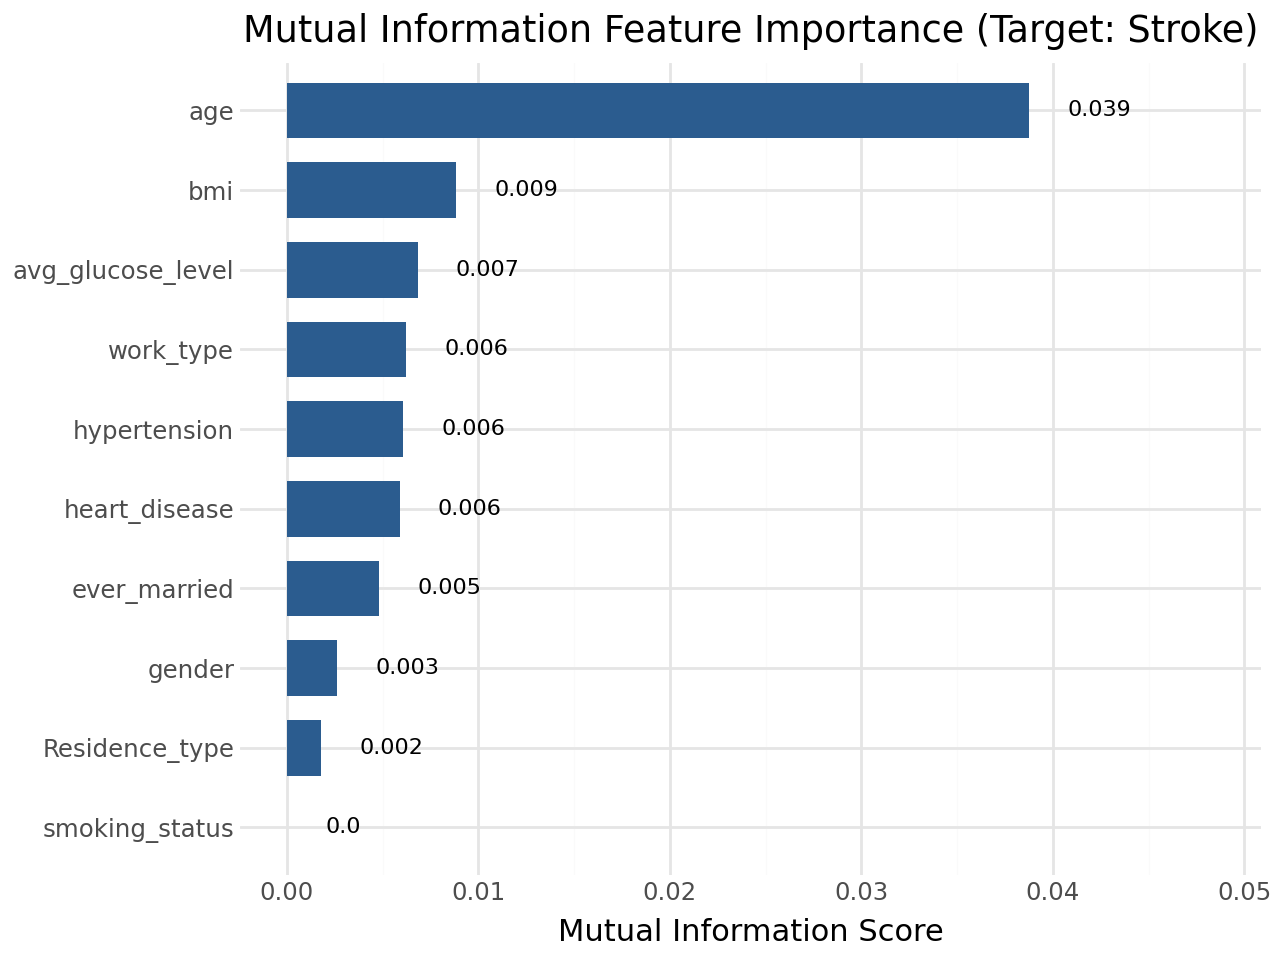

In [78]:
import pandas as pd
import plotnine as pln
from sklearn.feature_selection import mutual_info_classif

# Pre-encode categorical features temporarily for MI calculation
df_mi = df.copy()
for col in df_mi.select_dtypes(include=['object', 'category']).columns:
  df_mi[col] = df_mi[col].astype('category').cat.codes

X = df_mi.drop(columns=['stroke'])
y = df_mi['stroke']

# Identify discrete feature indices for exact MI calculation
discrete_features = [
    i for i, col in enumerate(X.columns) if X[col].dtype == 'int64'
]

# Calculate Mutual Information scores
mi_scores = mutual_info_classif(
    X, y, discrete_features=discrete_features, random_state=42
)

# Construct results DataFrame and format text labels
df_mi_results = pd.DataFrame({'Feature': X.columns, 'MI_Score': mi_scores})
df_mi_results = df_mi_results.sort_values(by='MI_Score', ascending=True)
df_mi_results['Feature'] = pd.Categorical(
    df_mi_results['Feature'],
    categories=df_mi_results['Feature'],
    ordered=True,
)
df_mi_results['MI_Score_label'] = (
    df_mi_results['MI_Score'].round(3).astype(str)
)

# Render plotnine visualization using ha and nudge_y for correct text offset
p_mi = (
    pln.ggplot(
        df_mi_results,
        pln.aes(x='Feature', y='MI_Score', label='MI_Score_label'),
    )
    + pln.geom_col(fill='#2b5c8f', width=0.7)
    + pln.geom_text(
        pln.aes(label='MI_Score_label'), ha='left', nudge_y=0.002, size=8
    )
    + pln.coord_flip()
    + pln.scale_y_continuous(
        limits=(0, max(df_mi_results['MI_Score']) * 1.25)
    )
    + pln.theme_minimal()
    + pln.labs(
        title='Mutual Information Feature Importance (Target: Stroke)',
        x='',
        y='Mutual Information Score',
    )
)

p_mi

### 3.4 *Conclusion*

#### *Section 3 Summary: Bivariate, Correlation & Feature Association Analysis*

This section evaluated feature interdependencies and target relationships using a three-tier analytical framework: **Pearson/Spearman correlations** for continuous features, **Cramér's V** for categorical associations, and **Mutual Information (MI)** for non-linear entropy reduction.

#### *1. Continuous Numerical Relationships (Pearson vs. Spearman)*


* **Primary Risk Driver:** `age` exhibits the strongest direct monotonic association with `stroke` ($\rho \approx 0.25$), serving as the dominant baseline demographic indicator.
* **Monotonic vs. Linear Divergence:** Spearman rank correlation values systematically exceed Pearson correlation values across skewed continuous predictors (`avg_glucose_level`, `bmi`). This divergence proves the presence of **non-linear threshold relationships**—stroke risk accelerates sharply past clinical tipping points rather than scaling linearly.
* **The BMI Paradox:** `bmi` demonstrates a weak direct correlation with `stroke` ($r \approx 0.05$). Bivariate analysis indicates that BMI functions as an indirect risk factor mediated primarily through `hypertension` and `avg_glucose_level`.

#### *2. Categorical & Demographic Associations (Cramér's V)*

* **Demographic Collinearity (`ever_married` $\leftrightarrow$ `work_type`):** High Cramér's V ($V > 0.35$) reflects structural age-driven collinearity. Pediatric entries (`work_type == 'children'`) strictly map to unmarried status, making both attributes proxies for age.
* **Structural Missingness Validation (`smoking_status`):** Moderate association between `smoking_status` and `work_type` confirms that `Unknown` entries cluster heavily within younger cohorts (MAR/MNAR). This validates the decision to retain `Unknown` as an explicit categorical level rather than imputing or dropping it.
* **Candidate Noise Feature:** `Residence_type` (Urban vs. Rural) demonstrates negligible statistical association ($V < 0.05$) across all attributes and the target variable, making it a primary candidate for feature pruning.

#### *3. Unified Information-Theoretic Importance (Mutual Information)*

* **Entropy Reduction Hierarchy:** Mutual Information $I(X; Y) = H(Y) - H(Y|X)$ computed via $k$-NN non-parametric estimation confirms `age` as the highest information-bearing feature, followed by `avg_glucose_level`, `hypertension`, and `heart_disease`.
* **Preprocessing Rationale:** Uninformative features showing near-zero MI scores (`Residence_type`, `gender`) provide no measurable uncertainty reduction regarding stroke risk and will be excluded during pipeline construction.

#### *Multicollinearity Analysis*

Multicollinearity occurs when two or more predictor variables are highly correlated, providing redundant information to the model. This redundancy makes it difficult for statistical algorithms to isolate the independent effect of each feature on the target variable (`stroke`), leading to unstable coefficients and inflated standard errors. In our stroke prediction dataset, **critical numerical multicollinearity is absent**: continuous features exhibit low-to-moderate linear correlations (e.g., Pearson's $r \approx 0.33$ between `age` and `bmi`, with all Variance Inflation Factors (VIF) remaining well below 2.0). However, **structural demographic collinearity** exists between `ever_married` and `work_type` (Cramér's $V > 0.35$). This stems naturally from age dynamics, as pediatric records (`work_type == 'children'`) strictly map to unmarried status, reflecting domain logic rather than a data quality defect.

#### *Strategic Recommendations for Preprocessing & Modeling*

* **Retain Continuous Medical Features:** Numerical features such as `bmi` and `avg_glucose_level` must be preserved. Despite clinical mediation, they contribute unique statistical variance and represent distinct clinical risk pathways.
* **Prune Uninformative Noise Features:** `Residence_type` should be removed prior to model execution due to near-zero statistical association ($V < 0.05$ and $\text{MI} \approx 0$). Additionally, evaluate the pruning of `ever_married` if it provides no additive predictive signal beyond `age`.
* **Select Robust Modeling Architectures:** Integrate algorithms into the `Pipeline` that inherently handle non-linear threshold patterns and mild demographic collinearity, specifically tree-based ensembles (e.g., Random Forest, XGBoost).

## 4. *Feature selection & Engineering*